# LIF v1 Visualization Notebook

This notebook generates the **v1 curated visualization set** and overwrites the dataset statistics JSON.

**Datasets used:**
- `data/refined/lif_exploits_final.csv`
- `data/refined/lif_all_interventions.csv`
- `data/refined/lif_intervention_metrics.csv`

**Outputs:**
- `visualizations/v1/*.png`
- `data/refined/lif_stats.json`

Run all cells from top to bottom.

In [54]:
import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

COLORS = {
    'background': '#F7FAFC',
    'ink': '#1F2937',
    'muted': '#6B7280',
    'blue': '#2563EB',
    'blue_light': '#93C5FD',
    'slate': '#64748B',
    'green': '#16A34A',
    'amber': '#D97706',
    'red': '#DC2626',
    'purple': '#7C3AED',
}

plt.rcParams.update({
    'figure.facecolor': COLORS['background'],
    'axes.facecolor': COLORS['background'],
    'axes.edgecolor': COLORS['blue_light'],
    'axes.labelcolor': COLORS['ink'],
    'xtick.color': COLORS['ink'],
    'ytick.color': COLORS['ink'],
    'text.color': COLORS['ink'],
    'axes.titleweight': 'bold',
    'axes.titlepad': 14,
    'figure.dpi': 150,
})

def find_project_root():
    cwd = Path.cwd().resolve()
    for parent in [cwd] + list(cwd.parents):
        if parent.name == 'legitimate-intervention-framework':
            return parent
    return cwd

BASE_DIR = find_project_root()
DATA_DIR = BASE_DIR / 'data' / 'refined'
VIZ_PATH = BASE_DIR / 'visualizations' / 'v1'
STATS_PATH = DATA_DIR / 'lif_stats.json'
VIZ_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig, filename):
    path = VIZ_PATH / filename
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'Saved: {path}')

print(f'Project root: {BASE_DIR}')
print(f'Visualization output: {VIZ_PATH}')

Project root: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework
Visualization output: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1


In [55]:
EXPLOITS_FILE = DATA_DIR / 'lif_exploits_final.csv'
ALL_INTERVENTIONS_FILE = DATA_DIR / 'lif_all_interventions.csv'
METRICS_FILE = DATA_DIR / 'lif_intervention_metrics.csv'

exploits_df = pd.read_csv(EXPLOITS_FILE)
all_interventions_df = pd.read_csv(ALL_INTERVENTIONS_FILE)
metrics_df = pd.read_csv(METRICS_FILE)

AUTHORITY_MAP = {
    'Protocol Team': 'Signer Set',
    'Security Council': 'Delegated Body',
}

def normalize_dates(df, column='date'):
    df[column] = pd.to_datetime(df[column], errors='coerce')
    df['year'] = df[column].dt.year
    return df

exploits_df = normalize_dates(exploits_df)
all_interventions_df = normalize_dates(all_interventions_df)
metrics_df = normalize_dates(metrics_df)

for col in ['loss_usd', 'loss_prevented_usd', 'time_to_detect_min', 'time_to_contain_min', 'containment_success_pct']:
    if col in exploits_df.columns:
        exploits_df[col] = pd.to_numeric(exploits_df[col], errors='coerce')
    if col in all_interventions_df.columns:
        all_interventions_df[col] = pd.to_numeric(all_interventions_df[col], errors='coerce')
    if col in metrics_df.columns:
        metrics_df[col] = pd.to_numeric(metrics_df[col], errors='coerce')

exploits_df['loss_usd'] = exploits_df['loss_usd'].fillna(0)
all_interventions_df['loss_usd'] = all_interventions_df['loss_usd'].fillna(0)
metrics_df['loss_usd'] = metrics_df['loss_usd'].fillna(0)
metrics_df['loss_prevented_usd'] = metrics_df['loss_prevented_usd'].fillna(0)

if 'authority_standardized' in all_interventions_df.columns:
    all_interventions_df['authority_standardized'] = all_interventions_df['authority_standardized'].fillna(
        all_interventions_df['authority'].replace(AUTHORITY_MAP)
    )
else:
    all_interventions_df['authority_standardized'] = all_interventions_df['authority'].replace(AUTHORITY_MAP)

metrics_df['authority_standardized'] = metrics_df['authority'].replace(AUTHORITY_MAP)

print(f'Loaded exploits: {len(exploits_df)}')
print(f'Loaded all interventions: {len(all_interventions_df)}')
print(f'Loaded intervention metrics: {len(metrics_df)}')

Loaded exploits: 703
Loaded all interventions: 102
Loaded intervention metrics: 30


In [56]:
def build_stats():
    total_exploits = len(exploits_df)
    total_loss = float(exploits_df['loss_usd'].sum())
    lif_df = exploits_df[exploits_df['is_lif_relevant'] == True]
    lif_relevant_exploits = int(len(lif_df))
    lif_relevant_loss = float(lif_df['loss_usd'].sum())

    start_date = exploits_df['date'].min().strftime('%Y-%m-%d')
    end_date = exploits_df['date'].max().strftime('%Y-%m-%d')

    top_protocol = (
        exploits_df.groupby('protocol')['loss_usd'].sum().sort_values(ascending=False).index[0]
    )

    top_10 = exploits_df.nlargest(10, 'loss_usd')[
        ['protocol', 'loss_usd', 'date', 'vector_category', 'chain', 'is_lif_relevant']
    ]
    top_10_list = []
    for _, row in top_10.iterrows():
        top_10_list.append({
            'protocol': row['protocol'],
            'loss_usd': float(row['loss_usd']),
            'date': row['date'].isoformat() if pd.notna(row['date']) else None,
            'vector_category': row['vector_category'],
            'chain': row['chain'],
            'is_lif_relevant': bool(row['is_lif_relevant']),
        })

    yearly_losses = exploits_df.groupby('year')['loss_usd'].sum().to_dict()
    yearly_losses = {str(k): float(v) for k, v in sorted(yearly_losses.items())}

    cumulative = {}
    running_total = 0
    for year in sorted(yearly_losses.keys()):
        running_total += yearly_losses[year]
        cumulative[year] = float(running_total)

    vector_dist = exploits_df['vector_category'].value_counts().to_dict()
    chain_losses = (
        exploits_df.groupby('chain')['loss_usd'].sum().sort_values(ascending=False).to_dict()
    )
    chain_losses = {str(k): float(v) for k, v in chain_losses.items()}

    intervention_scope = metrics_df['scope'].value_counts().to_dict()
    intervention_authority = metrics_df['authority'].value_counts().to_dict()
    intervention_loss_total = float(metrics_df['loss_usd'].sum())
    intervention_prevented_total = float(metrics_df['loss_prevented_usd'].sum())
    intervention_cases = int(len(metrics_df))

    avg_detect_time = float(metrics_df['time_to_detect_min'].mean())
    avg_contain_time = float(metrics_df['time_to_contain_min'].mean())
    avg_success_rate = float(metrics_df['containment_success_pct'].mean())
    median_detect_time = float(metrics_df['time_to_detect_min'].median())
    median_contain_time = float(metrics_df['time_to_contain_min'].median())

    all_interventions_total = int(len(all_interventions_df))
    all_interventions_loss = float(all_interventions_df['loss_usd'].sum())
    all_interventions_scope = all_interventions_df['scope'].value_counts().to_dict()
    all_interventions_authority = all_interventions_df['authority'].value_counts().to_dict()
    all_interventions_authority_std = all_interventions_df['authority_standardized'].value_counts().to_dict()

    all_interventions_yearly = all_interventions_df.groupby('year').size().to_dict()
    all_interventions_yearly_loss = (
        all_interventions_df.groupby('year')['loss_usd'].sum().to_dict()
    )

    recent_interventions = all_interventions_df[all_interventions_df['date'] >= '2025-01-01']
    recent_count = int(len(recent_interventions))
    recent_loss = float(recent_interventions['loss_usd'].sum())

    stats = {
        'summary': {
            'total_exploits': int(total_exploits),
            'total_loss_usd': total_loss,
            'lif_relevant_exploits': int(lif_relevant_exploits),
            'lif_relevant_loss_usd': lif_relevant_loss,
            'top_protocol': top_protocol,
            'date_range': {
                'start': start_date,
                'end': end_date,
            },
            'generated_at': datetime.now().isoformat(),
        },
        'top_10_exploits': top_10_list,
        'yearly_losses': yearly_losses,
        'cumulative_losses': cumulative,
        'vector_distribution': vector_dist,
        'chain_distribution': chain_losses,
        'intervention_metrics': {
            'total_cases': intervention_cases,
            'by_scope': intervention_scope,
            'by_authority': intervention_authority,
            'total_loss_usd': intervention_loss_total,
            'total_prevented_usd': intervention_prevented_total,
            'avg_detection_time_minutes': avg_detect_time,
            'median_detection_time_minutes': median_detect_time,
            'avg_containment_time_minutes': avg_contain_time,
            'median_containment_time_minutes': median_contain_time,
            'avg_success_rate_percent': avg_success_rate,
            'generated_at': datetime.now().isoformat(),
        },
        'all_interventions': {
            'total_cases': all_interventions_total,
            'total_loss_usd': all_interventions_loss,
            'by_scope': all_interventions_scope,
            'by_authority': all_interventions_authority,
            'by_authority_standardized': all_interventions_authority_std,
            'yearly_distribution': {str(k): int(v) for k, v in all_interventions_yearly.items()},
            'yearly_losses': {str(k): float(v) for k, v in all_interventions_yearly_loss.items()},
            'recent_2025_2026': {
                'cases': recent_count,
                'loss_usd': recent_loss,
            },
            'coverage_percentage': round((all_interventions_total / total_exploits) * 100, 2) if total_exploits > 0 else 0,
            'scope_coverage_notes': {
                'detailed_cases_includes': 'Module and Asset level interventions (governance responses, token freezes, preventative measures)',
                'all_interventions_includes': 'On-chain DeFi exploit interventions only (excludes infrastructure cases)',
                'reconciliation': '7 detailed cases represent broader intervention types outside exploit dataset scope: 4 Module cases (governance/risk management) + 3 Asset cases (issuer compliance actions)',
                'methodological_rationale': 'Dual-dataset approach enables comprehensive intervention analysis (30 cases) and focused DeFi exploit statistics (102 cases)',
            },
            'standardization_notes': {
                'infrastructure_cases_excluded': 1,
                'authority_mappings_applied': AUTHORITY_MAP,
                'defi_only': True,
            },
            'generated_at': datetime.now().isoformat(),
        },
        'data_sources': [
            'charoenwong_bernardi_table.txt',
            'rekt_database_raw.txt',
            'rekt_news_extra.txt',
            'defihacklabs_incidents.json',
            'manual_q4_2025_urls',
        ],
    }

    return stats

stats = build_stats()
with open(STATS_PATH, 'w') as f:
    json.dump(stats, f, indent=2)

print(f'Wrote stats: {STATS_PATH}')

Wrote stats: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/data/refined/lif_stats.json


## Exploit Landscape (LIF Dataset)

# Display inline charts
from IPython.display import display, Markdown

display(Markdown("### Exploit Landscape Overview"))
print("Generating exploit landscape charts...")

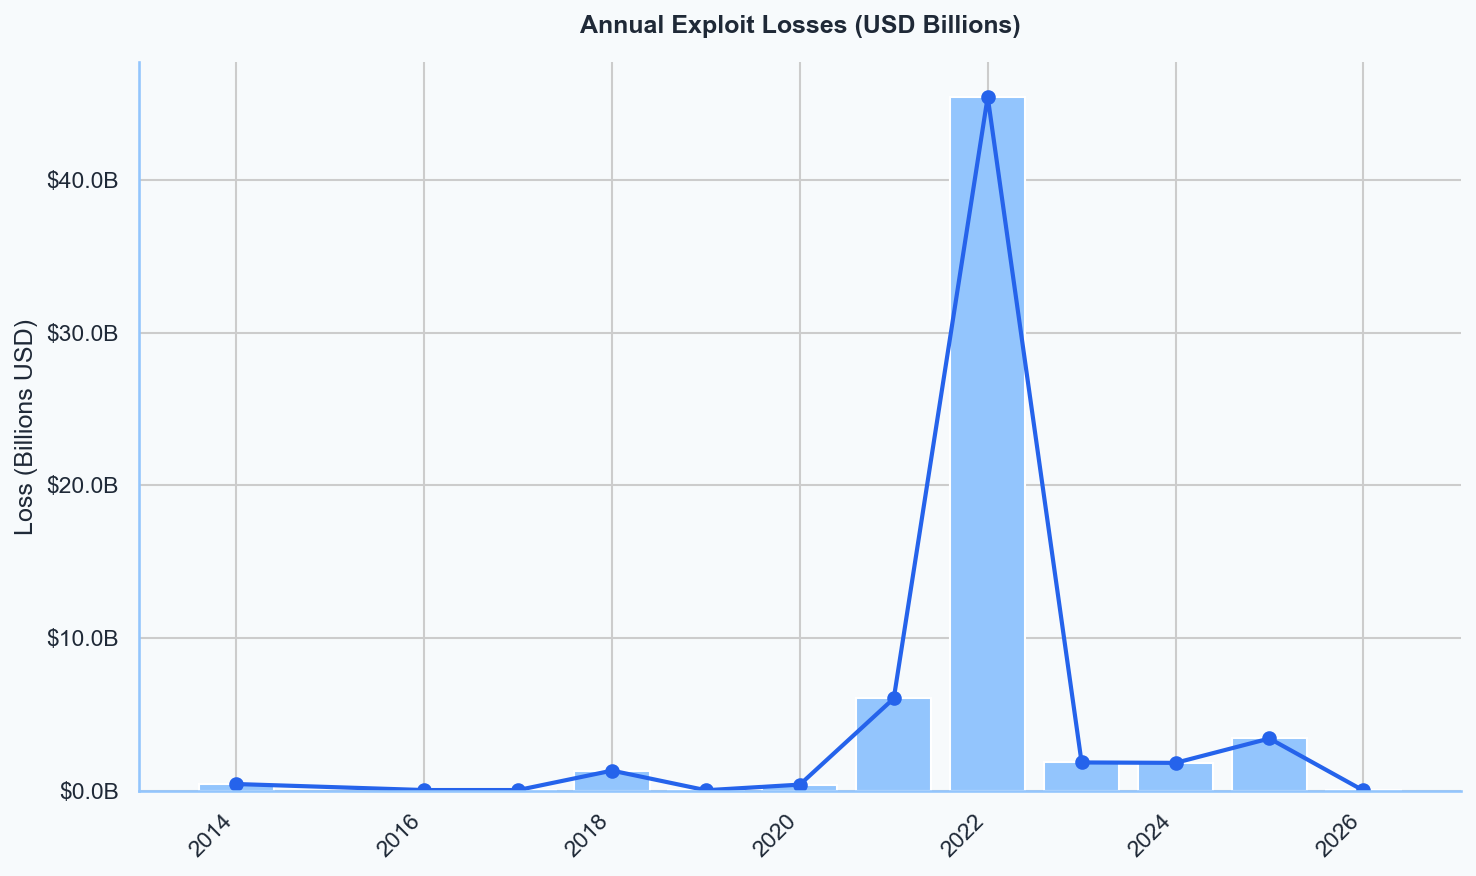

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_losses_by_year.png


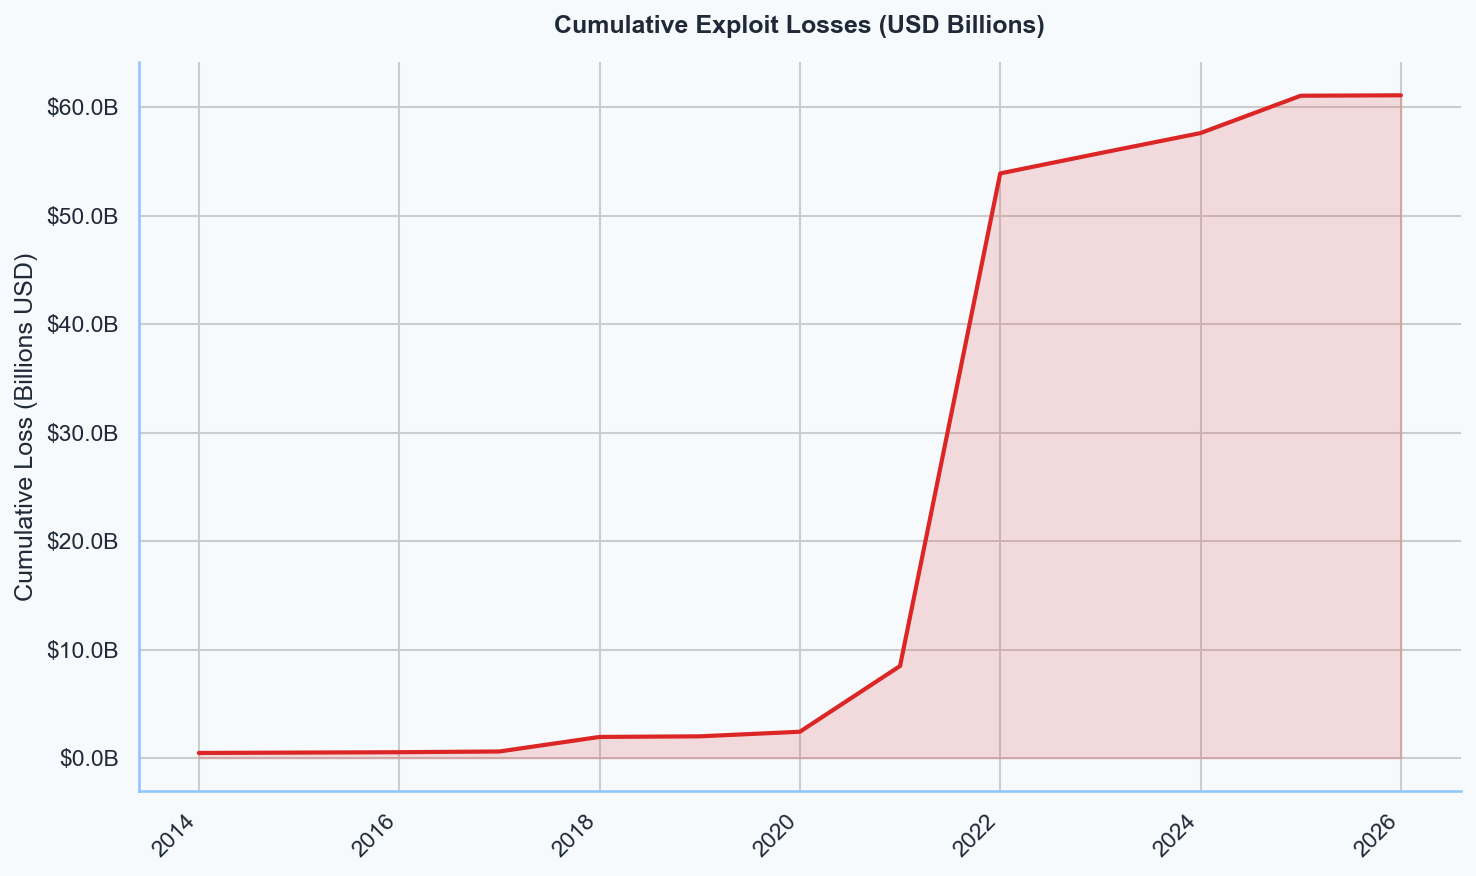

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_cumulative_losses.png


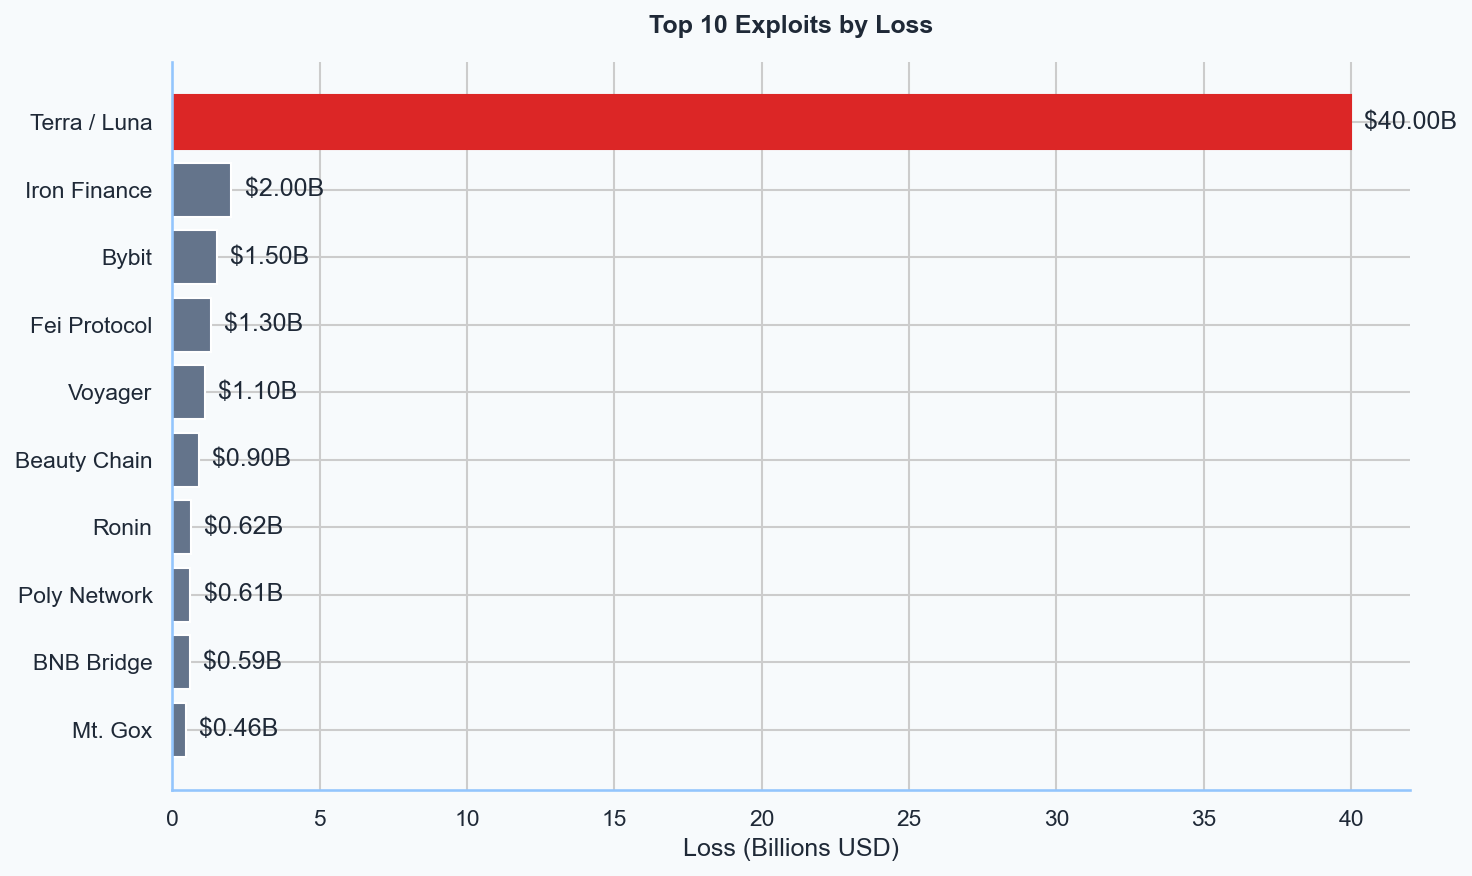

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_top10_exploits.png


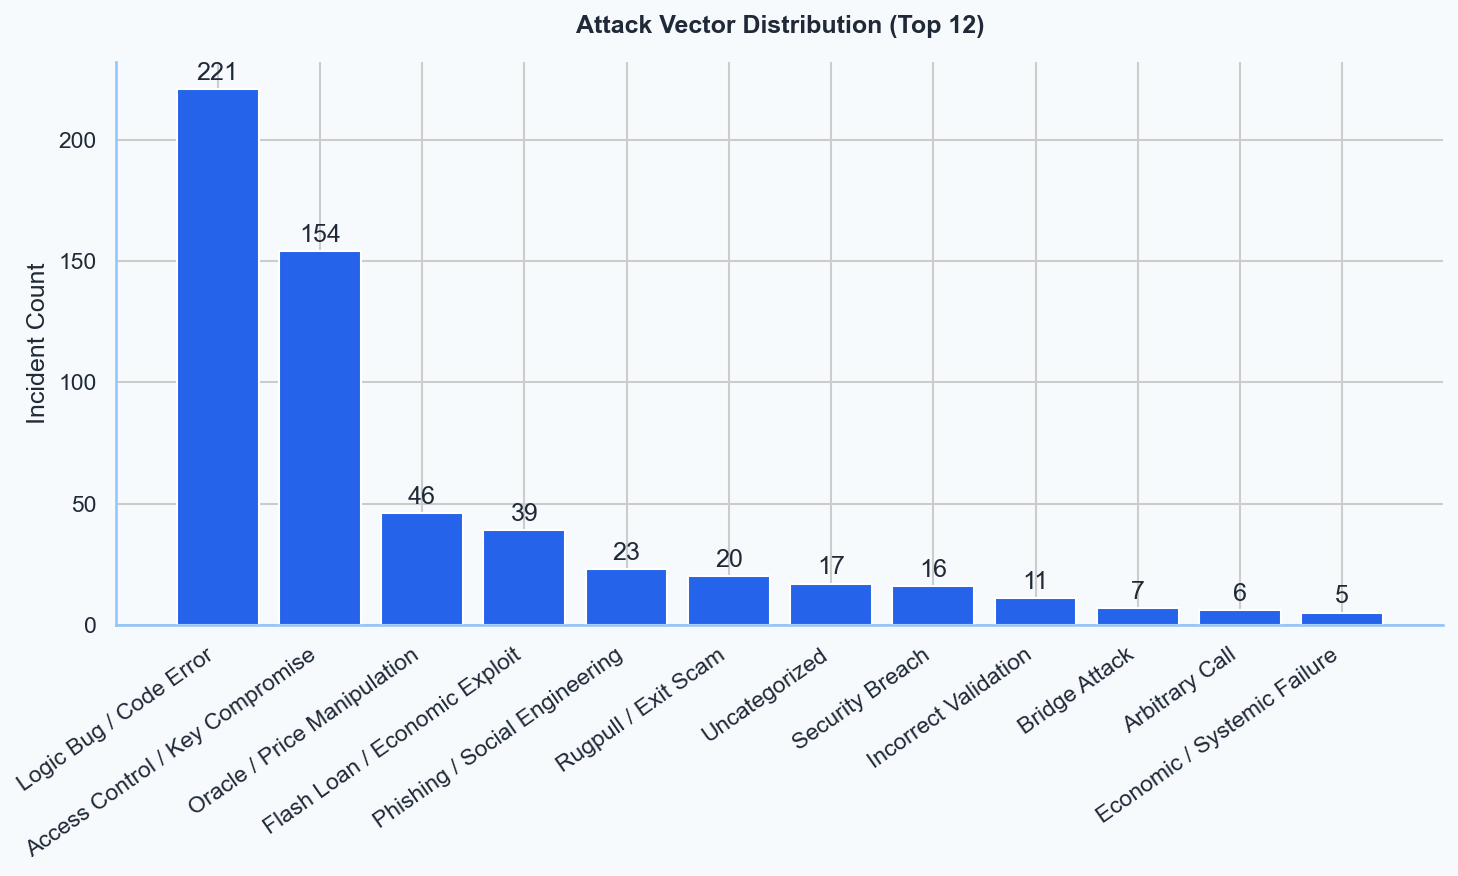

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_vector_distribution.png


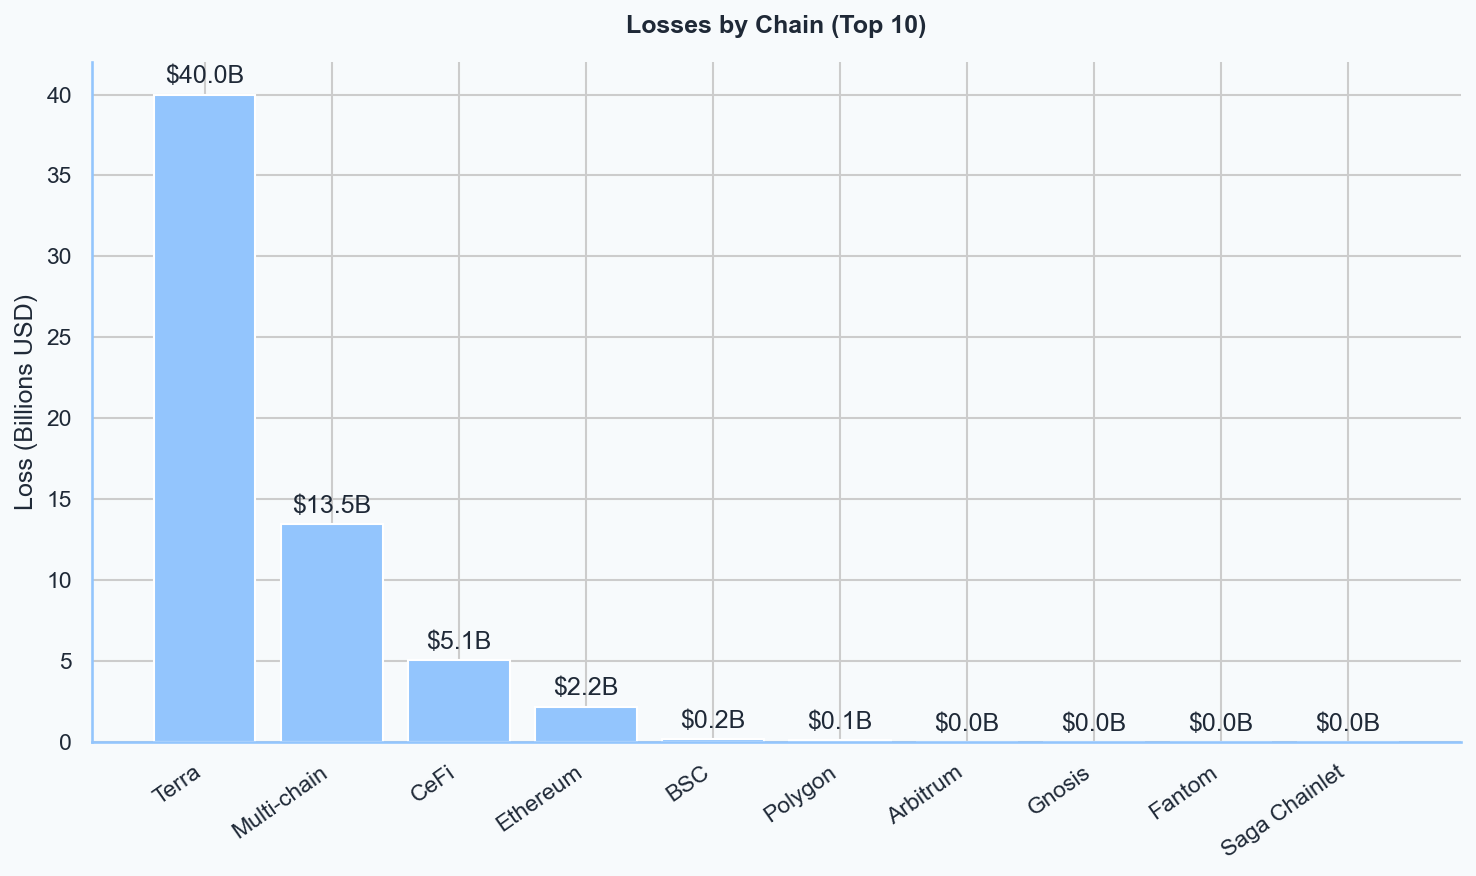

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_chain_distribution.png


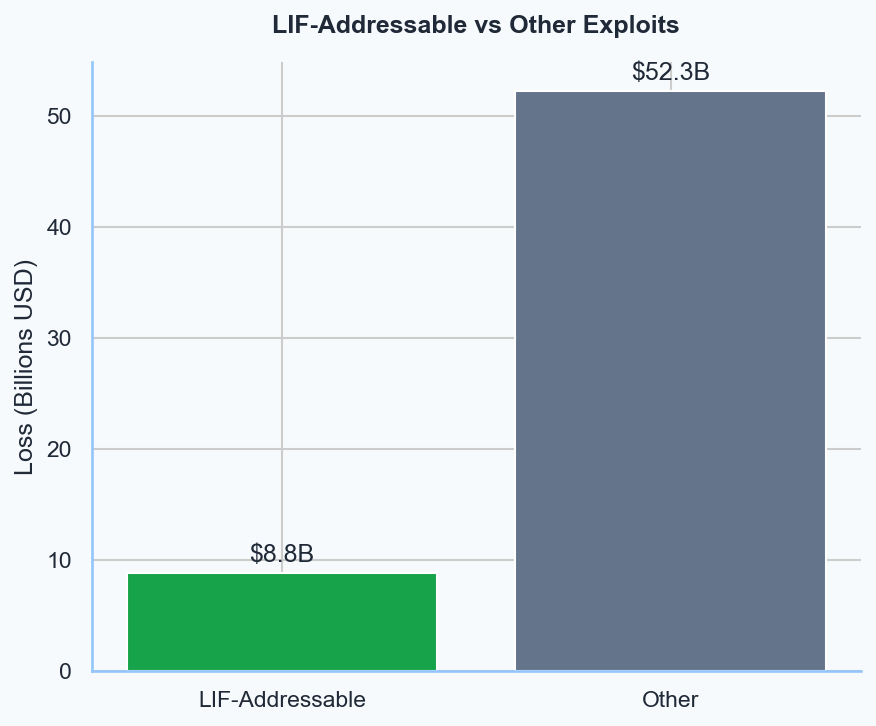

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_lif_addressable.png
Charts generated so far: 6


In [57]:
chart_count = 0

yearly_losses = exploits_df.groupby('year')['loss_usd'].sum().sort_index() / 1_000_000_000
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(yearly_losses.index, yearly_losses.values, color=COLORS['blue_light'])
ax.plot(yearly_losses.index, yearly_losses.values, color=COLORS['blue'], linewidth=2, marker='o')
ax.set_title('Annual Exploit Losses (USD Billions)')
ax.set_ylabel('Loss (Billions USD)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.1fB'))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_losses_by_year.png')
plt.close(fig)
chart_count += 1

cumulative = yearly_losses.cumsum()
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(cumulative.index, cumulative.values, color=COLORS['red'], alpha=0.15)
ax.plot(cumulative.index, cumulative.values, color=COLORS['red'], linewidth=2)
ax.set_title('Cumulative Exploit Losses (USD Billions)')
ax.set_ylabel('Cumulative Loss (Billions USD)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.1fB'))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_cumulative_losses.png')
plt.close(fig)
chart_count += 1

top10 = exploits_df.nlargest(10, 'loss_usd').copy()
top10['loss_billions'] = top10['loss_usd'] / 1_000_000_000
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['protocol'], top10['loss_billions'], color=COLORS['slate'])
bars[0].set_color(COLORS['red'])
ax.bar_label(bars, fmt=' $%.2fB', padding=3)
ax.set_title('Top 10 Exploits by Loss')
ax.set_xlabel('Loss (Billions USD)')
ax.invert_yaxis()
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_top10_exploits.png')
plt.close(fig)
chart_count += 1

vector_dist = exploits_df['vector_category'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(vector_dist.index, vector_dist.values, color=COLORS['blue'])
ax.bar_label(bars, padding=2)
ax.set_title('Attack Vector Distribution (Top 12)')
ax.set_ylabel('Incident Count')
plt.xticks(rotation=35, ha='right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_vector_distribution.png')
plt.close(fig)
chart_count += 1

chain_losses = (
    exploits_df.groupby('chain')['loss_usd'].sum().sort_values(ascending=False).head(10) / 1_000_000_000
)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(chain_losses.index, chain_losses.values, color=COLORS['blue_light'])
ax.bar_label(bars, fmt='$%.1fB', padding=3)
ax.set_title('Losses by Chain (Top 10)')
ax.set_ylabel('Loss (Billions USD)')
plt.xticks(rotation=35, ha='right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_chain_distribution.png')
plt.close(fig)
chart_count += 1

lif_losses = exploits_df[exploits_df['is_lif_relevant'] == True]['loss_usd'].sum() / 1_000_000_000
other_losses = exploits_df[exploits_df['is_lif_relevant'] != True]['loss_usd'].sum() / 1_000_000_000
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['LIF-Addressable', 'Other'], [lif_losses, other_losses], color=[COLORS['green'], COLORS['slate']])
ax.bar_label(bars, fmt='$%.1fB', padding=3)
ax.set_ylabel('Loss (Billions USD)')
ax.set_title('LIF-Addressable vs Other Exploits')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_lif_addressable.png')
plt.close(fig)
chart_count += 1

print(f'Charts generated so far: {chart_count}')

## All Interventions (102 DeFi Cases)

display(Markdown("### All Interventions Analysis"))
print("Generating all interventions charts...")

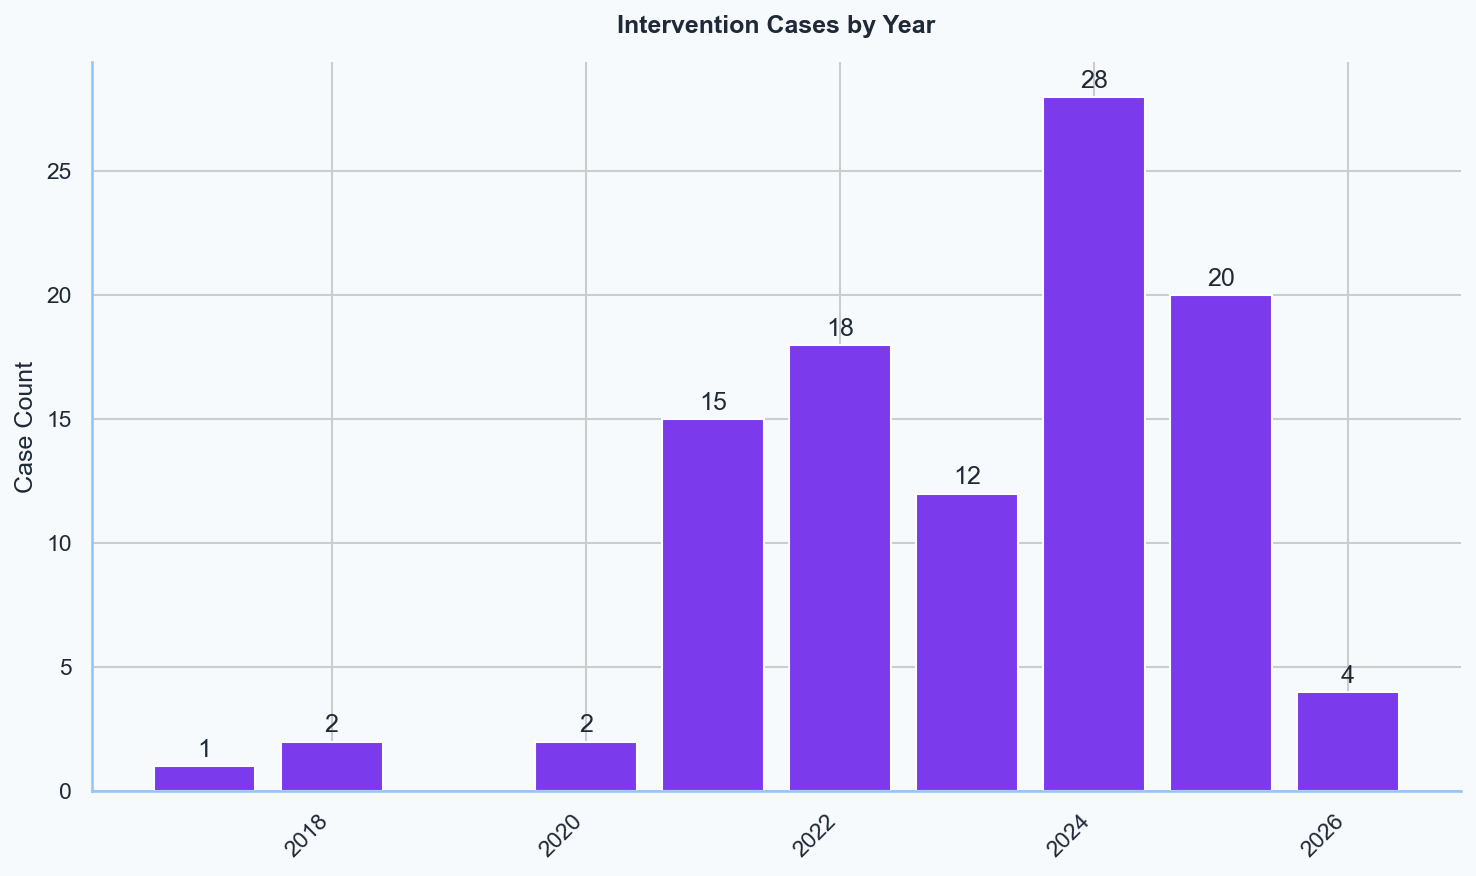

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_interventions_by_year.png


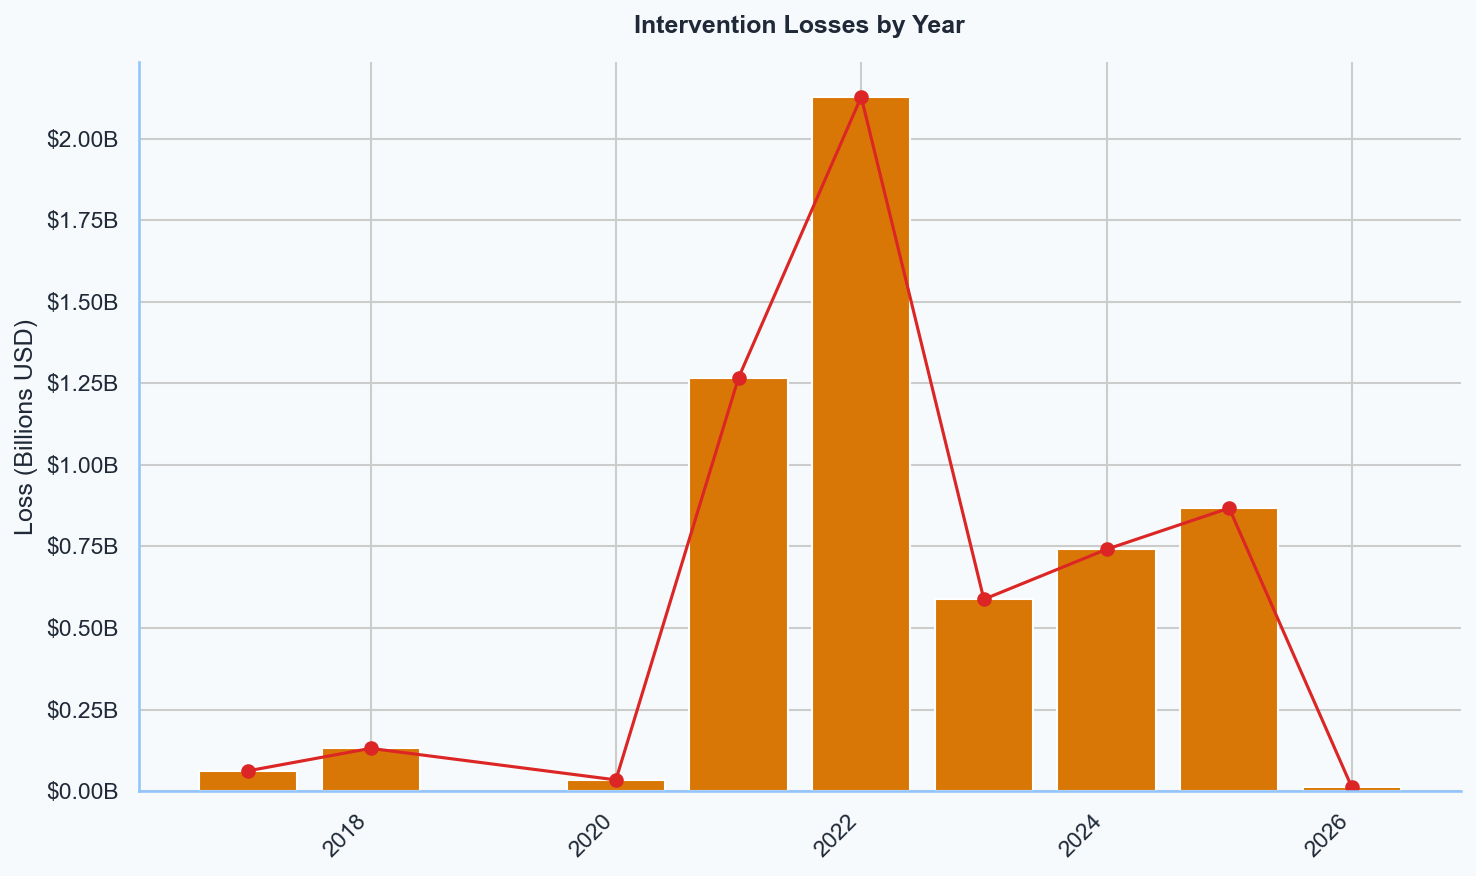

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_intervention_losses_by_year.png


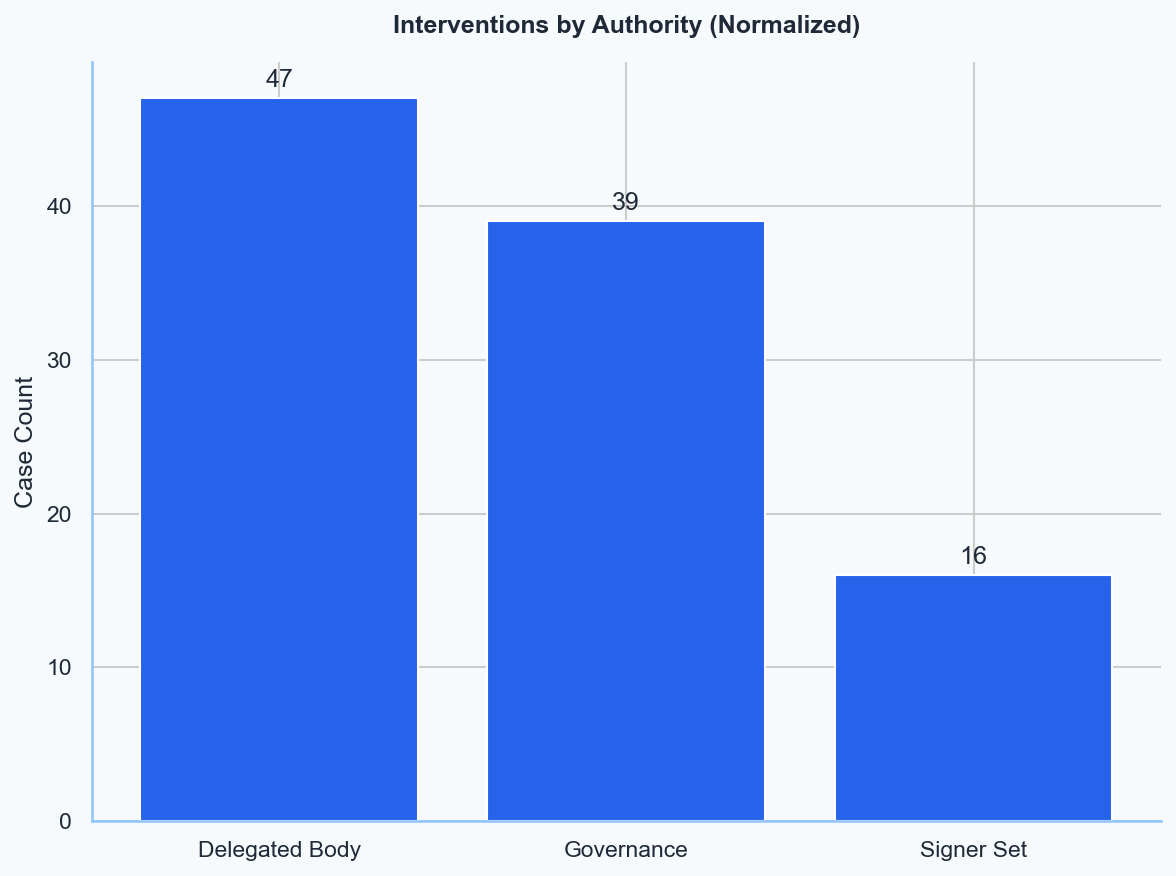

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_interventions_by_authority.png


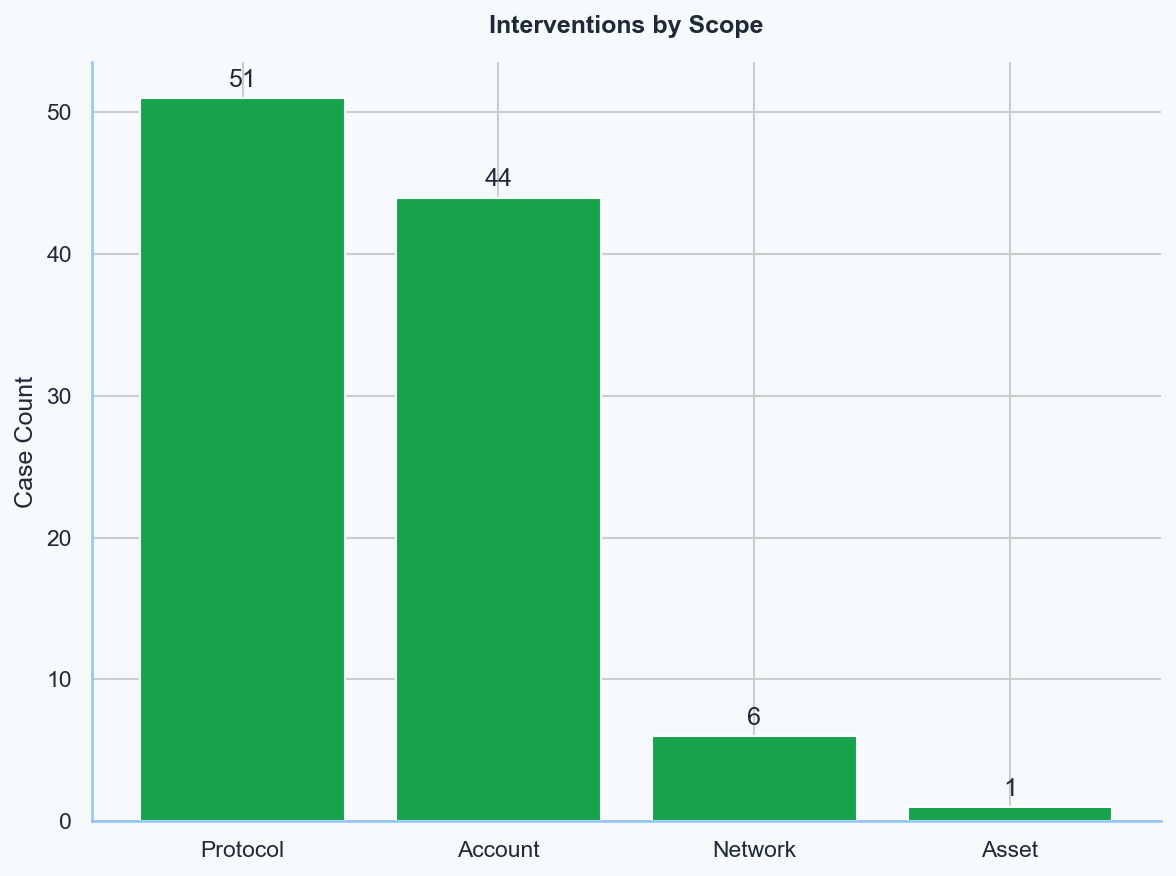

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_interventions_by_scope.png


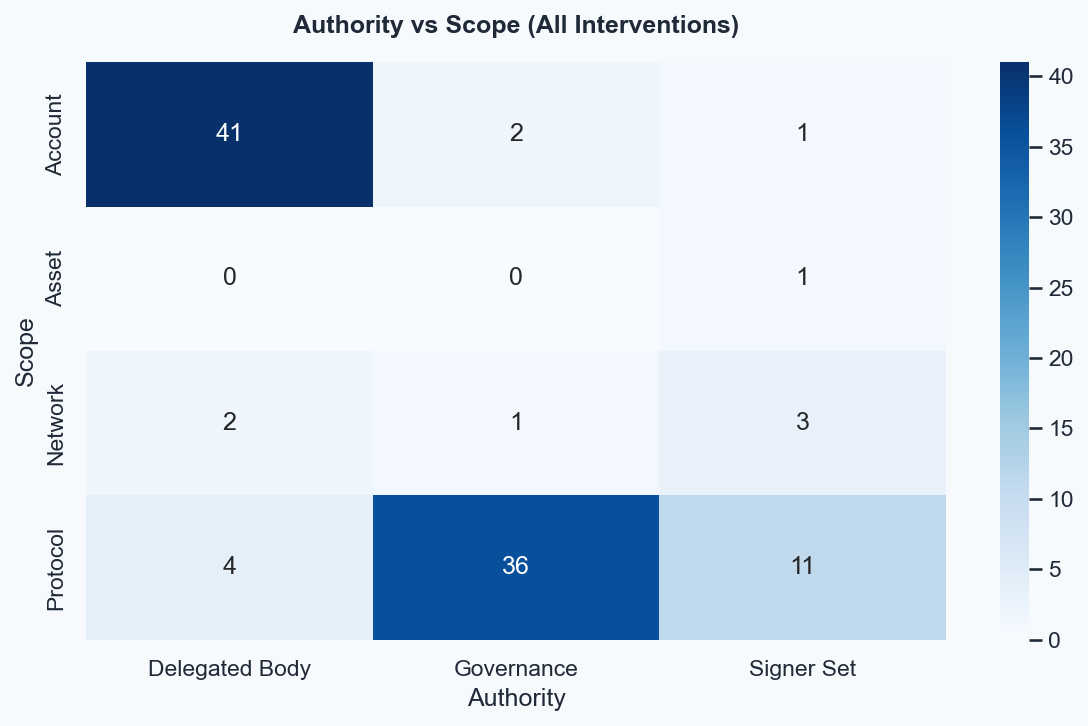

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_intervention_authority_scope_heatmap.png
Charts generated so far: 11


In [58]:
intervention_yearly = all_interventions_df.groupby('year').size().sort_index()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(intervention_yearly.index, intervention_yearly.values, color=COLORS['purple'])
ax.bar_label(bars, padding=2)
ax.set_title('Intervention Cases by Year')
ax.set_ylabel('Case Count')
plt.xticks(rotation=45, ha='right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_interventions_by_year.png')
plt.close(fig)
chart_count += 1

intervention_losses_yearly = (
    all_interventions_df.groupby('year')['loss_usd'].sum().sort_index() / 1_000_000_000
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(intervention_losses_yearly.index, intervention_losses_yearly.values, color=COLORS['amber'])
ax.plot(intervention_losses_yearly.index, intervention_losses_yearly.values, color=COLORS['red'], marker='o')
ax.set_title('Intervention Losses by Year')
ax.set_ylabel('Loss (Billions USD)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.2fB'))
plt.xticks(rotation=45, ha='right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_intervention_losses_by_year.png')
plt.close(fig)
chart_count += 1

authority_dist = all_interventions_df['authority_standardized'].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(authority_dist.index, authority_dist.values, color=COLORS['blue'])
ax.bar_label(bars, padding=3)
ax.set_title('Interventions by Authority (Normalized)')
ax.set_ylabel('Case Count')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_interventions_by_authority.png')
plt.close(fig)
chart_count += 1

scope_dist = all_interventions_df['scope'].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(scope_dist.index, scope_dist.values, color=COLORS['green'])
ax.bar_label(bars, padding=3)
ax.set_title('Interventions by Scope')
ax.set_ylabel('Case Count')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_interventions_by_scope.png')
plt.close(fig)
chart_count += 1

scope_authority = pd.crosstab(all_interventions_df['scope'], all_interventions_df['authority_standardized'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(scope_authority, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Authority vs Scope (All Interventions)')
ax.set_xlabel('Authority')
ax.set_ylabel('Scope')
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_intervention_authority_scope_heatmap.png')
plt.close(fig)
chart_count += 1

print(f'Charts generated so far: {chart_count}')

## Detailed Intervention Metrics (30 Cases)

display(Markdown("### Detailed Intervention Metrics"))
print("Generating detailed metrics charts...")

### 📊 Detailed Intervention Metrics

Generating detailed intervention metrics charts...


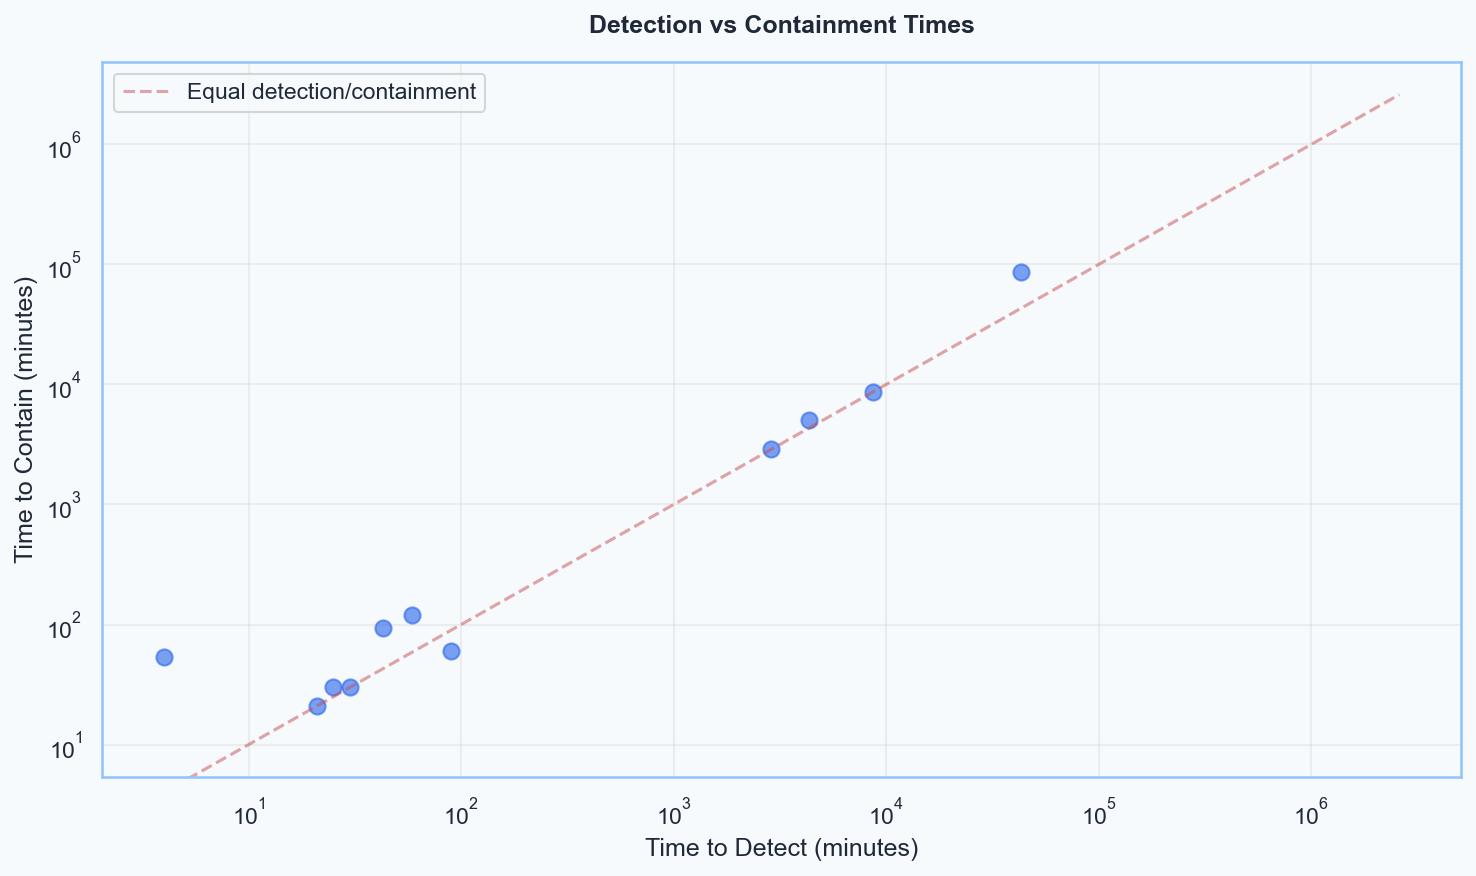

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_detection_vs_containment_times.png


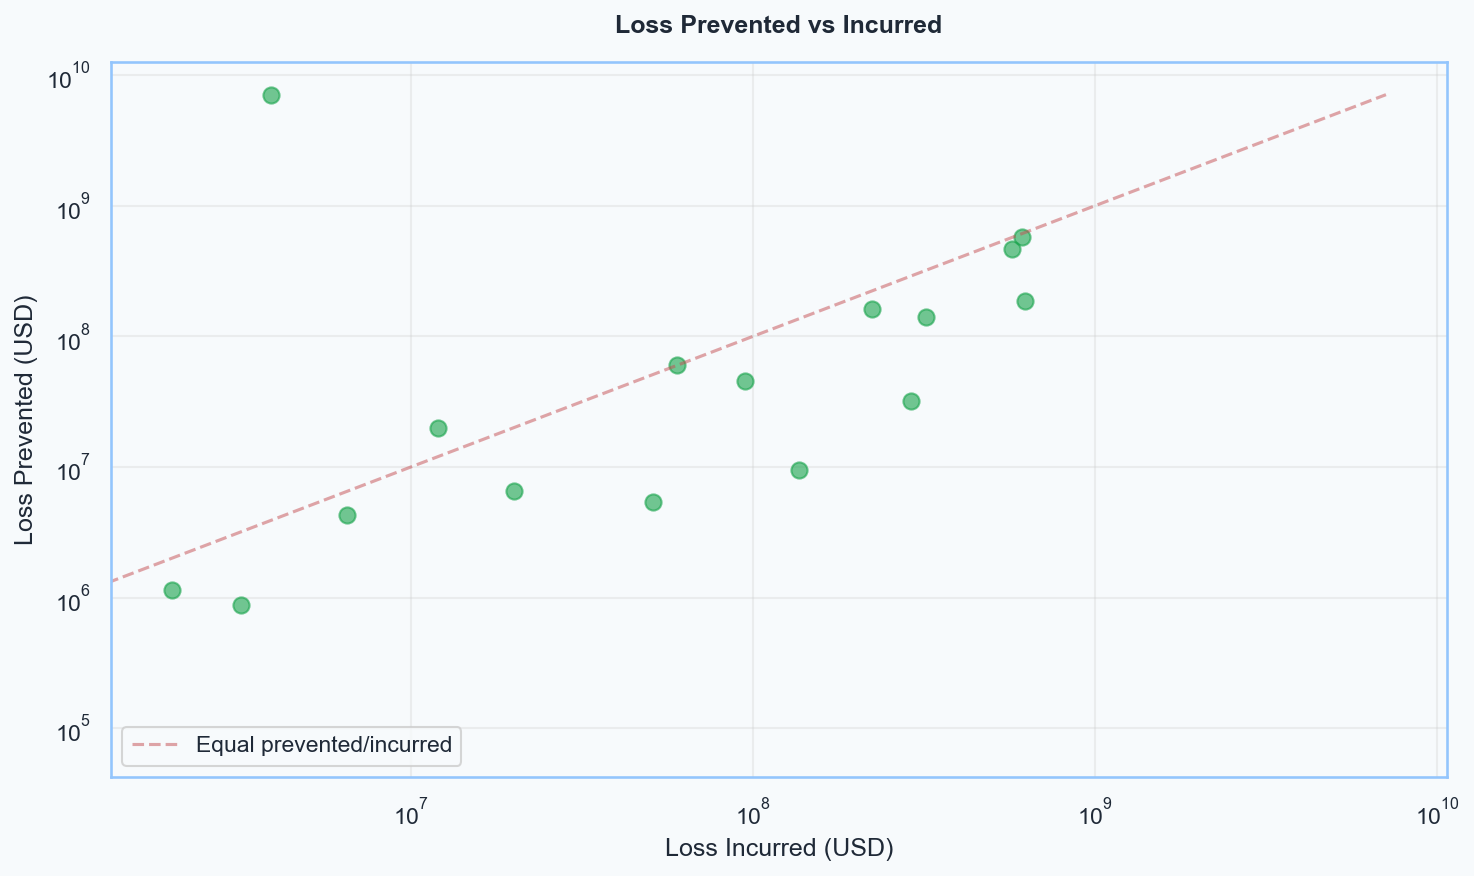

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_loss_prevented_vs_incurred.png


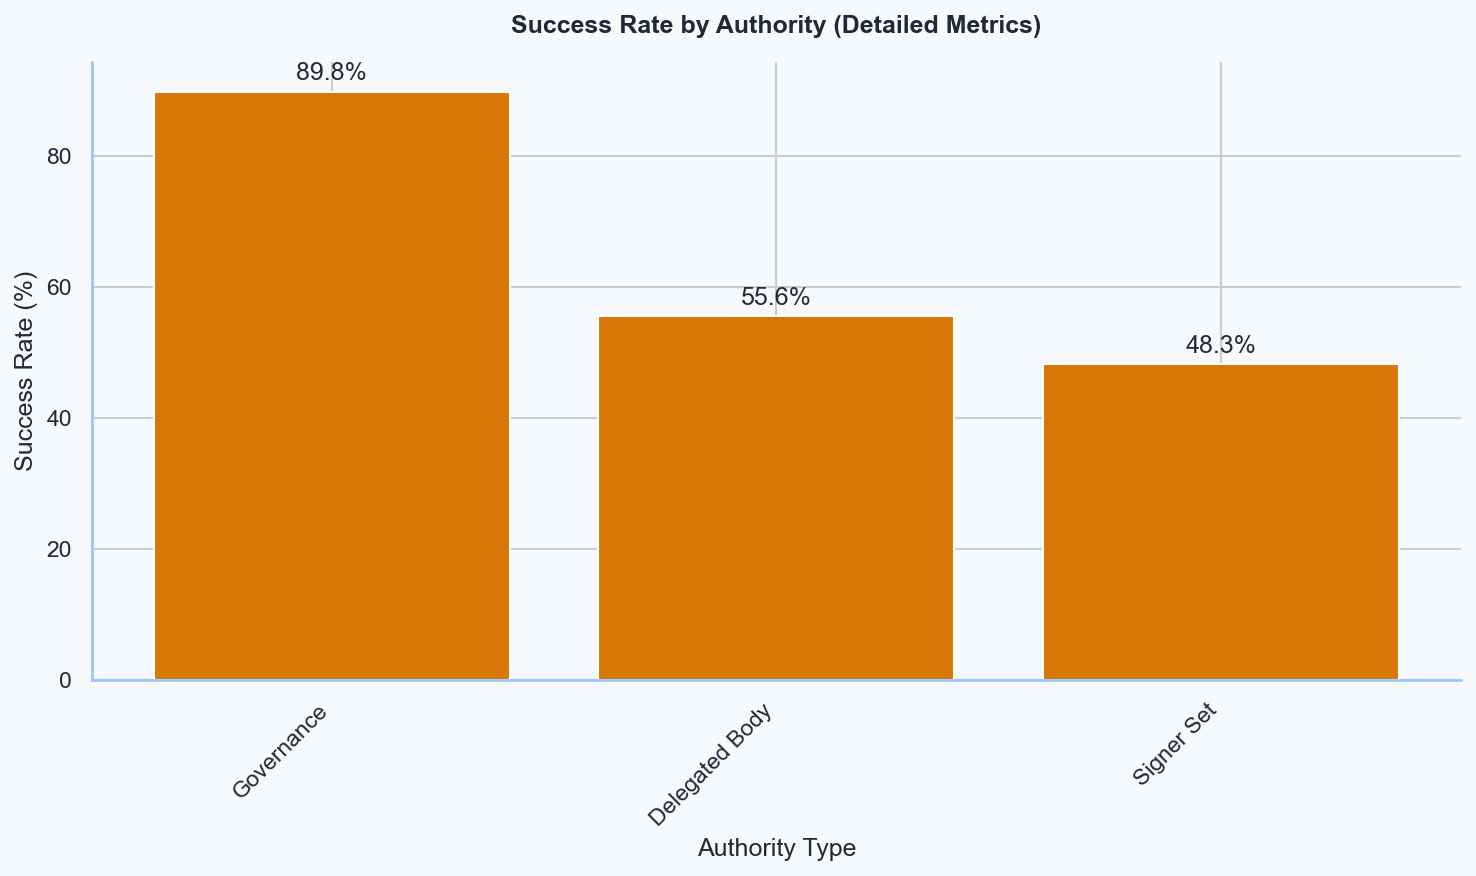

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_success_rate_by_authority_detailed.png


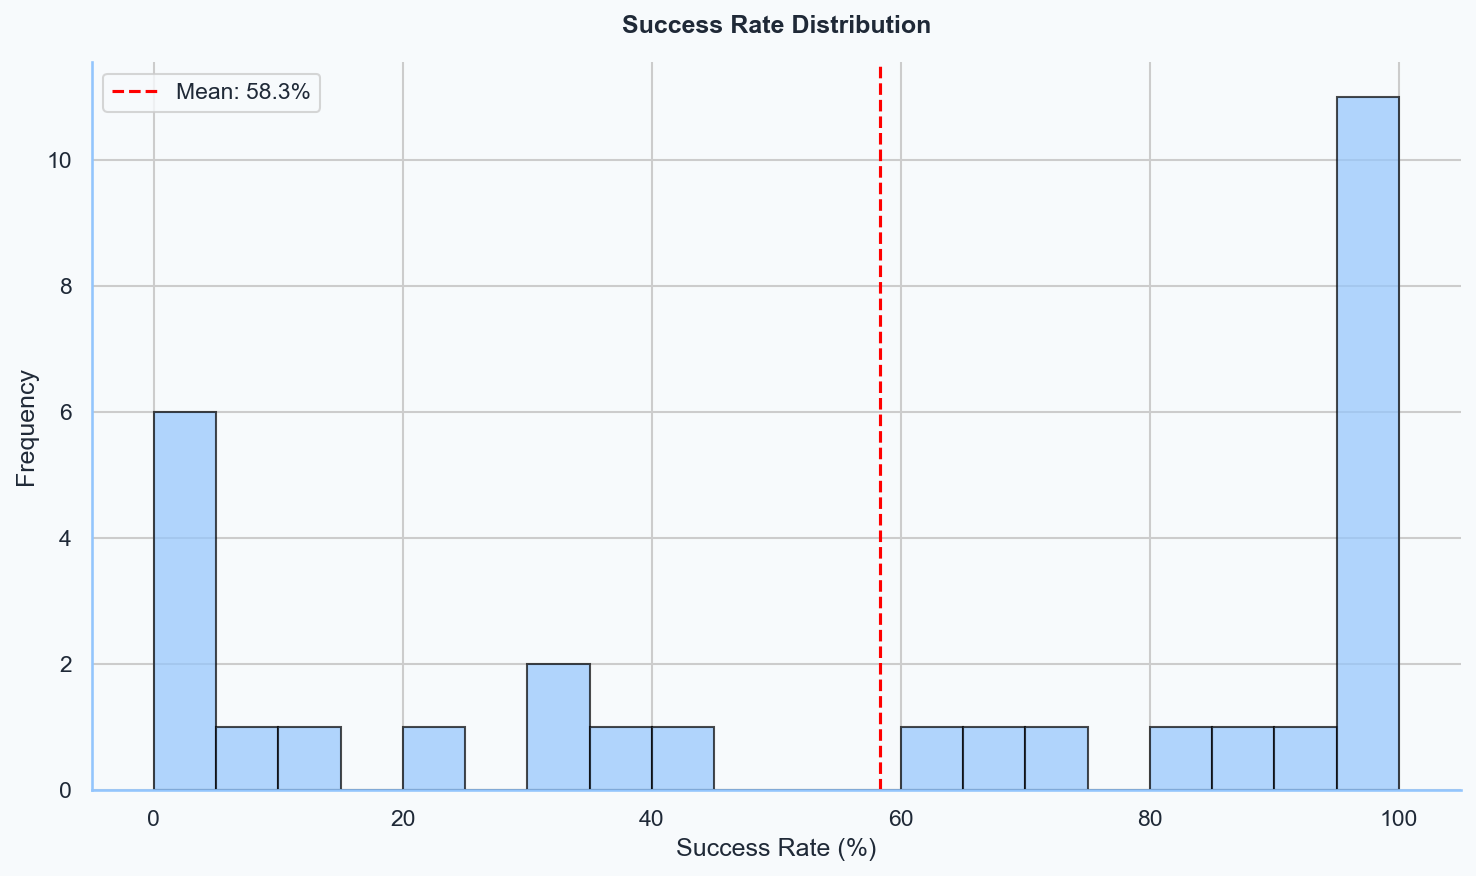

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_success_rate_distribution.png


KeyError: 'scope_category'

In [59]:
## Detailed Intervention Metrics Analysis

display(Markdown("### 📊 Detailed Intervention Metrics"))
print("Generating detailed intervention metrics charts...")

# 1. Detection vs Containment Times
time_metrics = metrics_df[['time_to_detect_min', 'time_to_contain_min']].copy()
time_metrics = time_metrics.dropna()

if len(time_metrics) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(time_metrics['time_to_detect_min'], time_metrics['time_to_contain_min'], 
              alpha=0.6, s=60, color=COLORS['blue'])
    
    # Add diagonal line for reference
    max_time = max(time_metrics['time_to_detect_min'].max(), time_metrics['time_to_contain_min'].max())
    ax.plot([0, max_time], [0, max_time], 'r--', alpha=0.5, label='Equal detection/containment')
    
    ax.set_xlabel('Time to Detect (minutes)')
    ax.set_ylabel('Time to Contain (minutes)')
    ax.set_title('Detection vs Containment Times')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    save_fig(fig, 'v1_detection_vs_containment_times.png')
    plt.close(fig)
    chart_count += 1

# 2. Loss Prevented vs Incurred
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(metrics_df['loss_usd'], metrics_df['loss_prevented_usd'], 
          alpha=0.6, s=60, color=COLORS['green'])

# Add diagonal line for reference
max_loss = max(metrics_df['loss_usd'].max(), metrics_df['loss_prevented_usd'].max())
ax.plot([0, max_loss], [0, max_loss], 'r--', alpha=0.5, label='Equal prevented/incurred')

ax.set_xlabel('Loss Incurred (USD)')
ax.set_ylabel('Loss Prevented (USD)')
ax.set_title('Loss Prevented vs Incurred')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_loss_prevented_vs_incurred.png')
plt.close(fig)
chart_count += 1

# 3. Success Rate by Authority
authority_success = metrics_df.groupby('authority_standardized')['containment_success_pct'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(authority_success.index, authority_success.values, color=COLORS['amber'])
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Success Rate by Authority (Detailed Metrics)')
ax.set_ylabel('Success Rate (%)')
ax.set_xlabel('Authority Type')
plt.xticks(rotation=45, ha='right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_success_rate_by_authority_detailed.png')
plt.close(fig)
chart_count += 1

# 4. Success Rate Distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(metrics_df['containment_success_pct'], bins=20, alpha=0.7, color=COLORS['blue_light'], edgecolor='black')
ax.axvline(metrics_df['containment_success_pct'].mean(), color='red', linestyle='--', 
          label=f'Mean: {metrics_df["containment_success_pct"].mean():.1f}%')
ax.set_xlabel('Success Rate (%)')
ax.set_ylabel('Frequency')
ax.set_title('Success Rate Distribution')
ax.legend()
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_success_rate_distribution.png')
plt.close(fig)
chart_count += 1

# 5. Authority vs Scope Heatmap for Detailed Metrics
authority_scope_matrix = pd.crosstab(
    metrics_df['authority_standardized'], 
    metrics_df['scope_category'],
    values=metrics_df['containment_success_pct'],
    aggfunc='mean'
)

if not authority_scope_matrix.empty:
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(authority_scope_matrix, annot=True, fmt='.1f', cmap='RdYlGn', 
                ax=ax, cbar_kws={'label': 'Success Rate (%)'})
    ax.set_title('Authority vs Scope Success Rate Heatmap (Detailed Metrics)')
    ax.set_xlabel('Scope Category')
    ax.set_ylabel('Authority Type')
    plt.tight_layout()
    plt.show()
    save_fig(fig, 'v1_authority_scope_heatmap_detailed.png')
    plt.close(fig)
    chart_count += 1

# 6. Scope Distribution for Detailed Metrics
scope_counts = metrics_df['scope_category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(scope_counts.index, scope_counts.values, color=COLORS['purple'], alpha=0.7)
ax.bar_label(bars, padding=3)
ax.set_title('Scope Distribution (Detailed Metrics)')
ax.set_ylabel('Number of Cases')
ax.set_xlabel('Scope Category')
plt.xticks(rotation=45, ha='right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_scope_distribution_detailed.png')
plt.close(fig)
chart_count += 1

print(f"Detailed intervention metrics charts generated. Total charts: {chart_count}")

## Detailed vs All Interventions (Distribution Comparison)

display(Markdown("### Distribution Comparison"))
print("Generating comparison charts...")

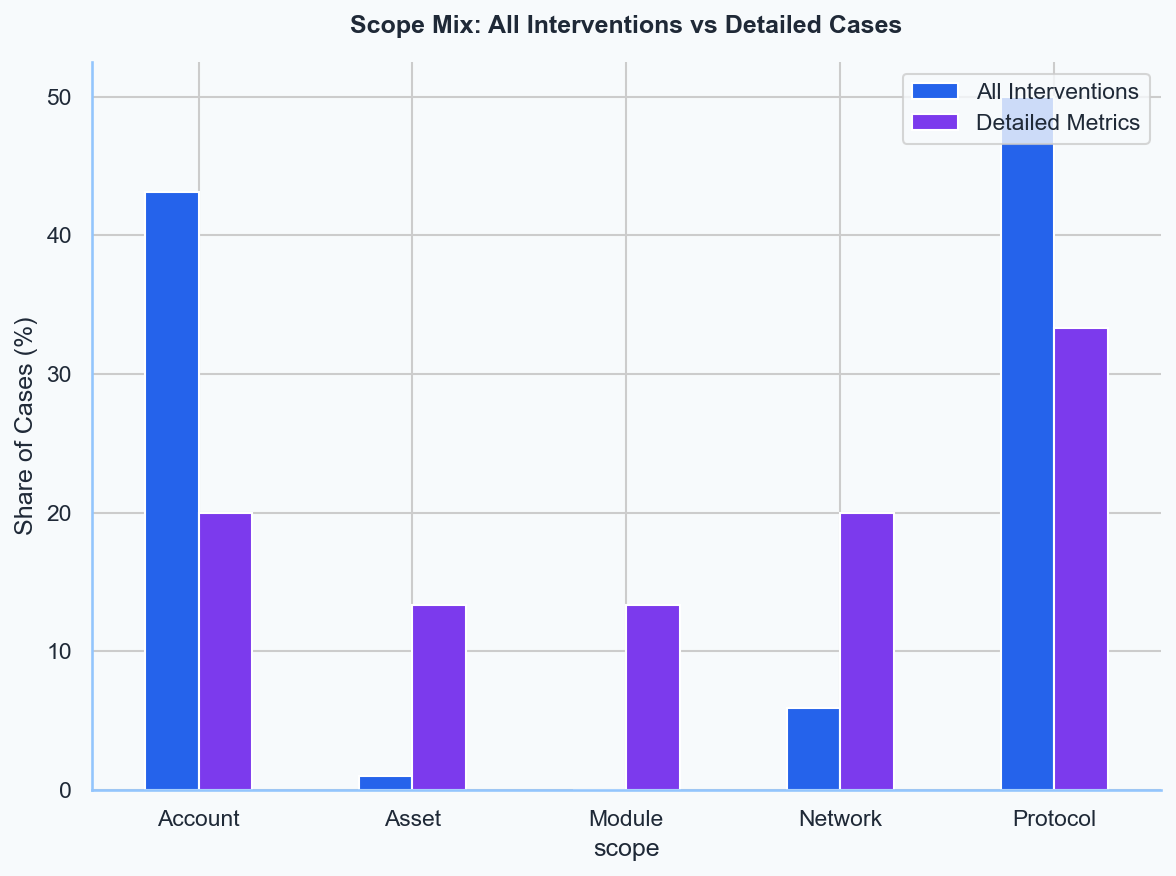

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_scope_comparison.png


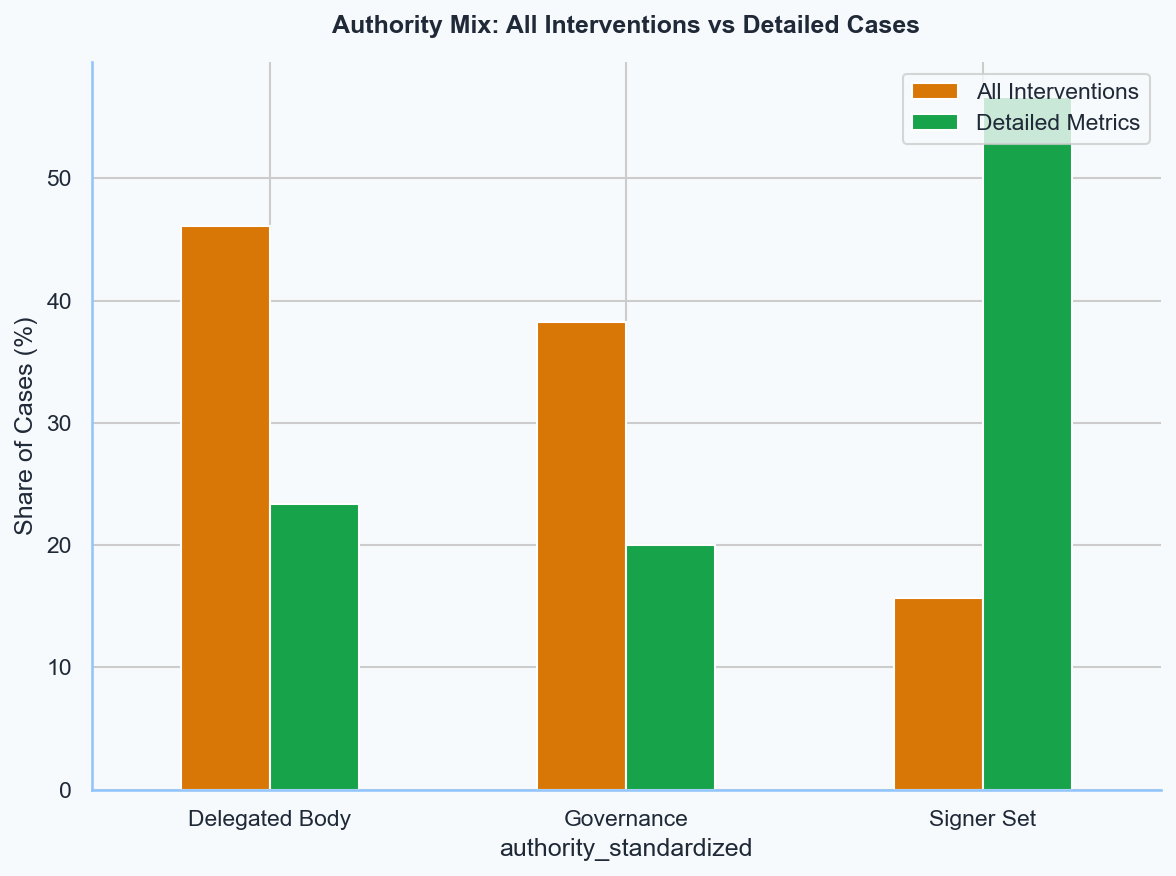

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_authority_comparison.png
Total v1 charts generated: 17


In [ ]:
scope_all = all_interventions_df['scope'].value_counts(normalize=True) * 100
scope_detailed = metrics_df['scope'].value_counts(normalize=True) * 100
scope_compare = pd.DataFrame({
    'All Interventions': scope_all,
    'Detailed Metrics': scope_detailed,
}).fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
scope_compare.plot(kind='bar', ax=ax, color=[COLORS['blue'], COLORS['purple']])
ax.set_title('Scope Mix: All Interventions vs Detailed Cases')
ax.set_ylabel('Share of Cases (%)')
ax.legend(loc='upper right')
plt.xticks(rotation=0)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_scope_comparison.png')
plt.close(fig)
chart_count += 1

authority_all = all_interventions_df['authority_standardized'].value_counts(normalize=True) * 100
authority_detailed = metrics_df['authority_standardized'].value_counts(normalize=True) * 100
authority_compare = pd.DataFrame({
    'All Interventions': authority_all,
    'Detailed Metrics': authority_detailed,
}).fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
authority_compare.plot(kind='bar', ax=ax, color=[COLORS['amber'], COLORS['green']])
ax.set_title('Authority Mix: All Interventions vs Detailed Cases')
ax.set_ylabel('Share of Cases (%)')
ax.legend(loc='upper right')
plt.xticks(rotation=0)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_authority_comparison.png')
plt.close(fig)
chart_count += 1

print(f'Total v1 charts generated: {chart_count}')

In [ ]:
## Summary Statistics

from IPython.display import display, Markdown

display(Markdown("### Dataset Summary"))
print(f"📊 **Dataset Overview**")
print(f"- Total exploits: {len(exploits_df):,}")
print(f"- LIF-relevant exploits: {len(exploits_df[exploits_df['is_lif_relevant'] == True]):,}")
print(f"- All interventions (DeFi): {len(all_interventions_df)}")
print(f"- Detailed intervention metrics: {len(metrics_df)}")
print(f"- Charts generated: {chart_count}")
print(f"- Stats saved to: {STATS_PATH}")
print(f"- Visualizations saved to: {VIZ_PATH}")

# Show authority mapping explanation
display(Markdown("### Authority Normalization"))
print("🔧 **Why we normalize authority names:**")
print("")
print("1. **Consistency**: Different protocols use different terms for similar entities")
print("   - 'Protocol Team' → 'Signer Set' (technical implementers)")
print("   - 'Security Council' → 'Delegated Body' (governance authorities)")
print("")
print("2. **Comparability**: Enables cross-protocol analysis and trend identification")
print("")
print("3. **Clarity**: Standardized terms are more intuitive for analysis")
print("")
print("The mapping preserves the original data while making it analysis-ready.")

### Dataset Summary

📊 **Dataset Overview**
- Total exploits: 703
- LIF-relevant exploits: 413
- All interventions (DeFi): 102
- Detailed intervention metrics: 30
- Charts generated: 17
- Stats saved to: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/data/refined/lif_stats.json
- Visualizations saved to: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1


### Authority Normalization

🔧 **Why we normalize authority names:**

1. **Consistency**: Different protocols use different terms for similar entities
   - 'Protocol Team' → 'Signer Set' (technical implementers)
   - 'Security Council' → 'Delegated Body' (governance authorities)

2. **Comparability**: Enables cross-protocol analysis and trend identification

3. **Clarity**: Standardized terms are more intuitive for analysis

The mapping preserves the original data while making it analysis-ready.


### Enhanced Visualizations

Generating additional analytical charts...


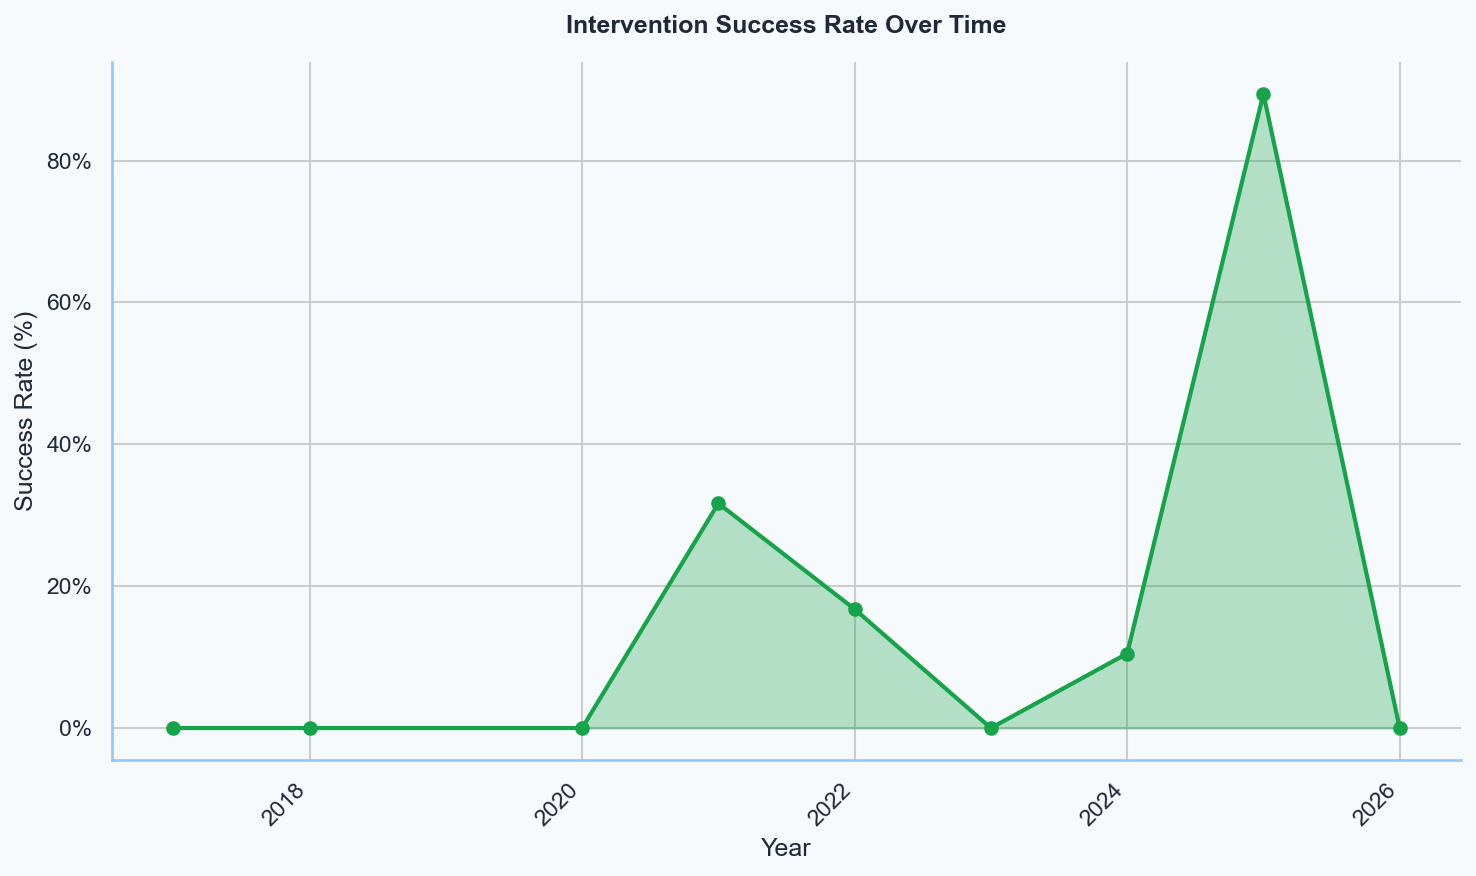

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_success_rate_timeline.png


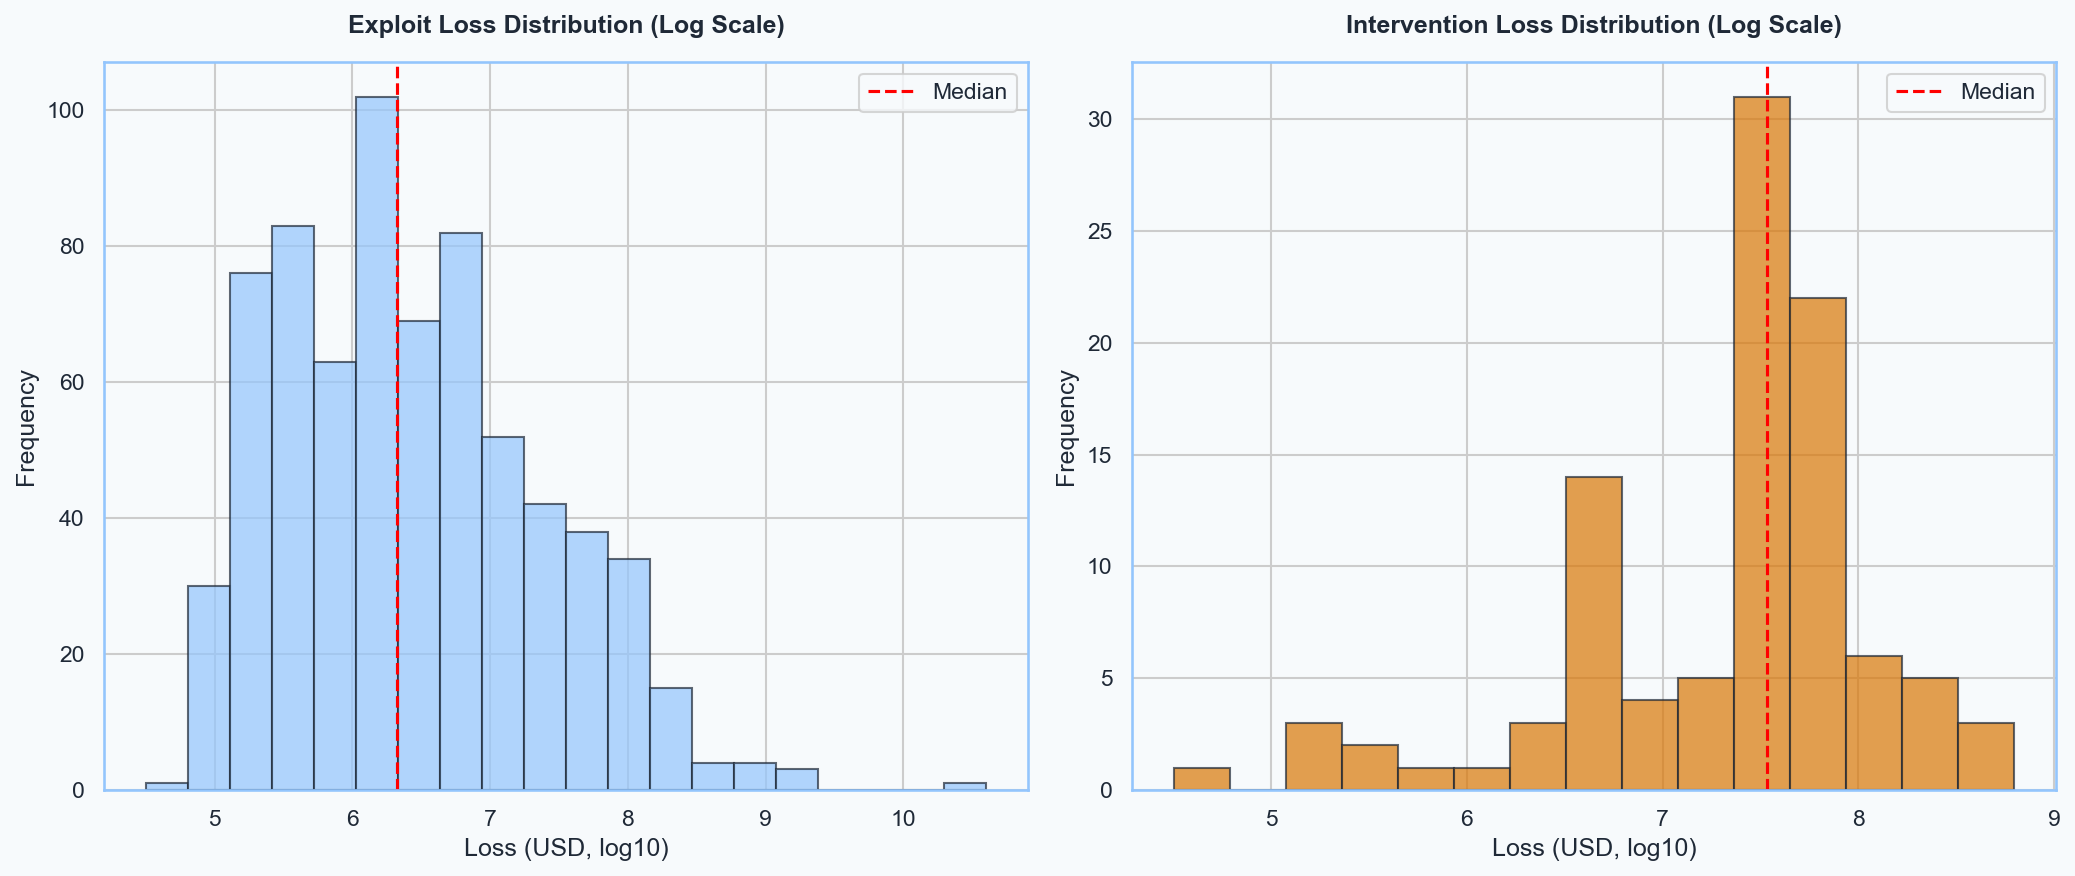

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_loss_distribution_comparison.png


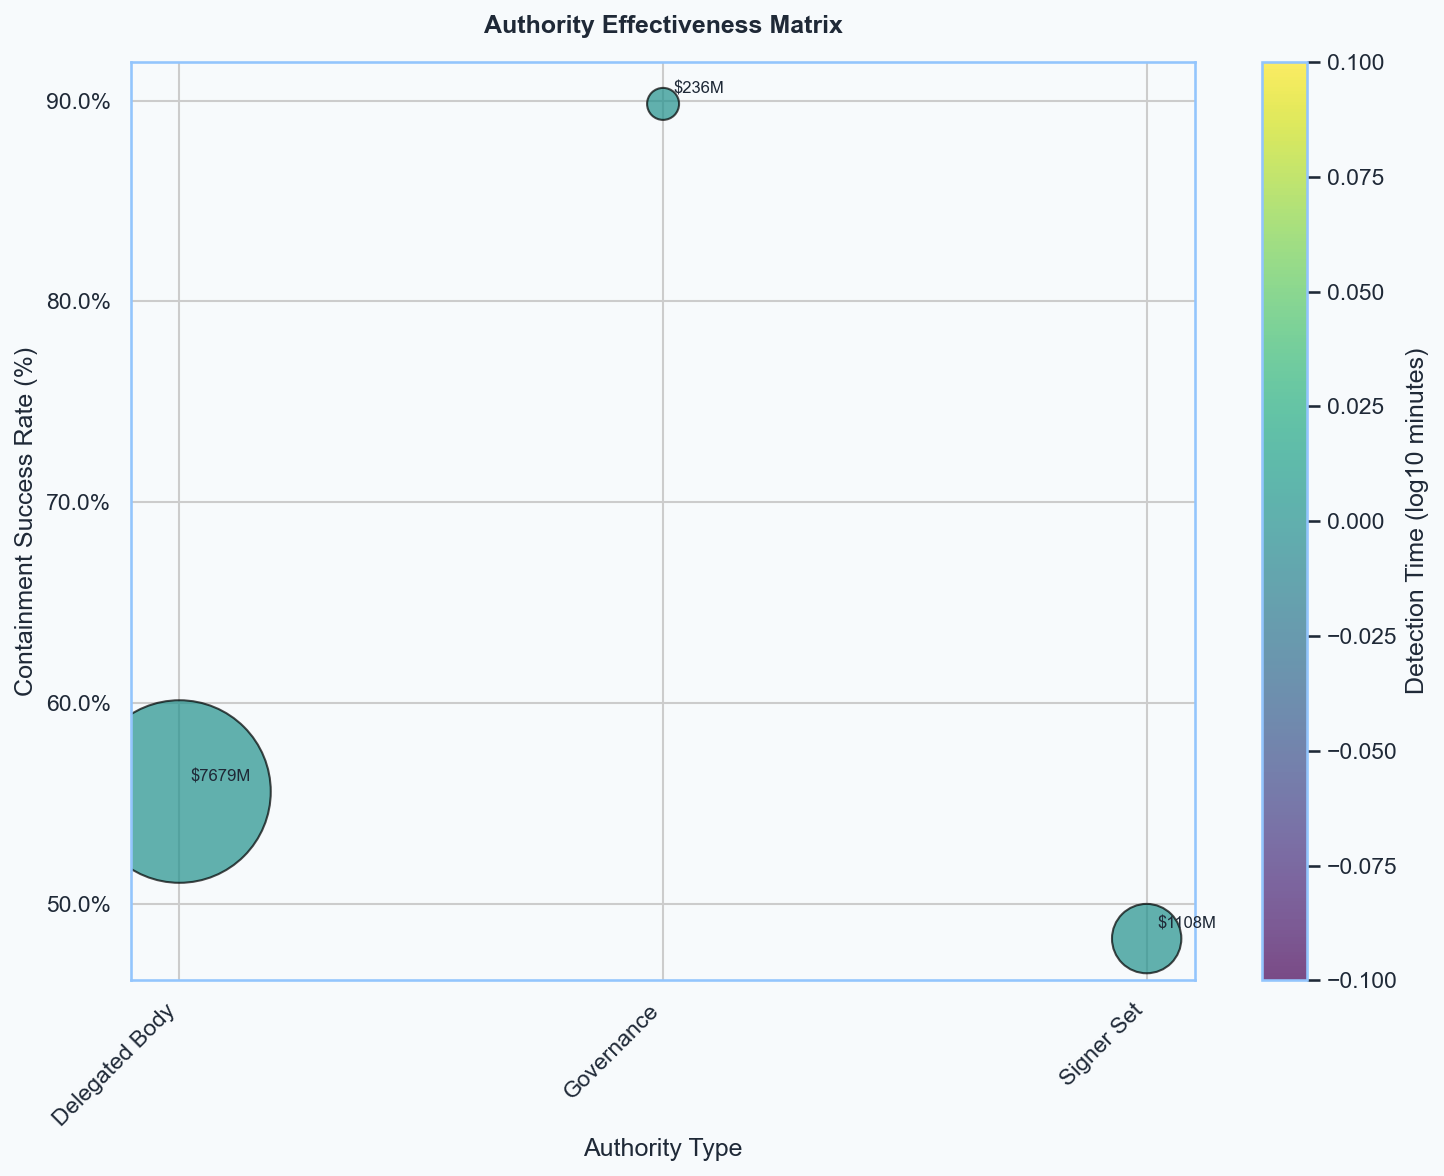

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_authority_effectiveness_matrix.png


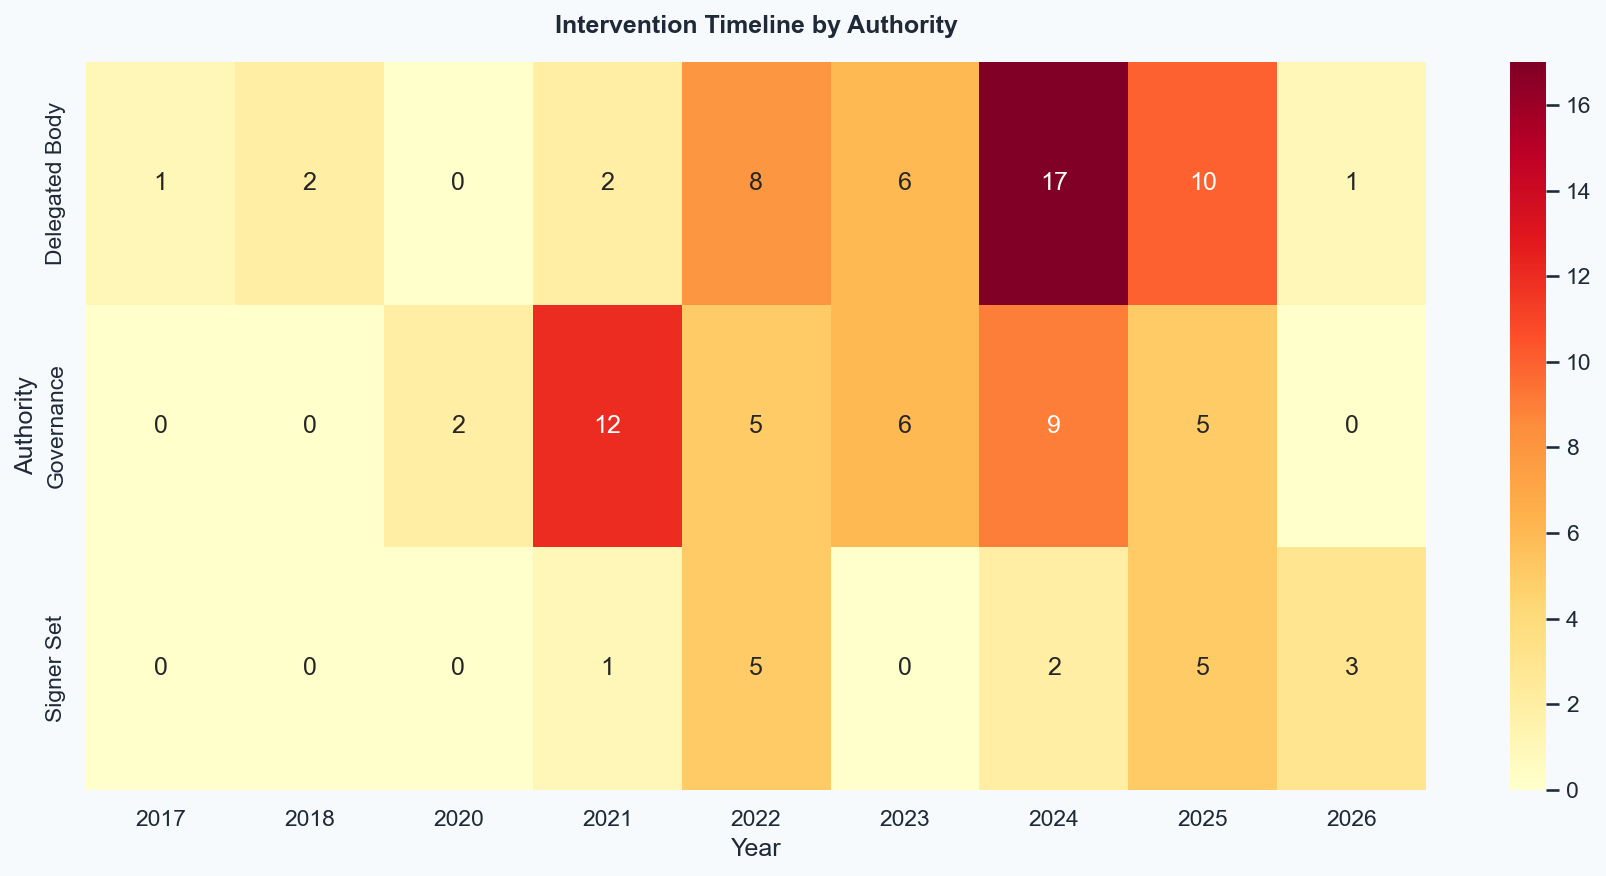

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_intervention_timeline_heatmap.png
Additional charts generated. Total charts: 21


In [ ]:
## Additional Advanced Charts

display(Markdown("### Enhanced Visualizations"))
print("Generating additional analytical charts...")

# 1. Intervention Success Rate Over Time
success_by_year = all_interventions_df.groupby('year').apply(
    lambda x: (x['loss_prevented_usd'].sum() / (x['loss_usd'].sum() + x['loss_prevented_usd'].sum())) * 100
).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(success_by_year.index, success_by_year.values, marker='o', linewidth=2, color=COLORS['green'])
ax.fill_between(success_by_year.index, success_by_year.values, alpha=0.3, color=COLORS['green'])
ax.set_title('Intervention Success Rate Over Time')
ax.set_ylabel('Success Rate (%)')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=45, ha='right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_success_rate_timeline.png')
plt.close(fig)
chart_count += 1

# 2. Loss Magnitude Distribution (Log Scale)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# All exploits
ax1.hist(np.log10(exploits_df['loss_usd'][exploits_df['loss_usd'] > 0]), 
         bins=20, color=COLORS['blue_light'], edgecolor=COLORS['ink'], alpha=0.7)
ax1.set_title('Exploit Loss Distribution (Log Scale)')
ax1.set_xlabel('Loss (USD, log10)')
ax1.set_ylabel('Frequency')
ax1.axvline(np.log10(exploits_df['loss_usd'].median()), color='red', linestyle='--', label='Median')
ax1.legend()

# Intervention losses
intervention_losses = all_interventions_df['loss_usd'][all_interventions_df['loss_usd'] > 0]
if len(intervention_losses) > 0:
    ax2.hist(np.log10(intervention_losses), 
             bins=15, color=COLORS['amber'], edgecolor=COLORS['ink'], alpha=0.7)
    ax2.set_title('Intervention Loss Distribution (Log Scale)')
    ax2.set_xlabel('Loss (USD, log10)')
    ax2.set_ylabel('Frequency')
    ax2.axvline(np.log10(intervention_losses.median()), color='red', linestyle='--', label='Median')
    ax2.legend()

plt.tight_layout()
plt.show()
save_fig(fig, 'v1_loss_distribution_comparison.png')
plt.close(fig)
chart_count += 1

# 3. Authority Effectiveness Matrix
authority_metrics = metrics_df.groupby('authority_standardized').agg({
    'containment_success_pct': 'mean',
    'time_to_detect_min': 'median',
    'time_to_contain_min': 'median',
    'loss_prevented_usd': 'sum',
    'loss_usd': 'sum'
}).fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
x_pos = np.arange(len(authority_metrics))
success_rates = authority_metrics['containment_success_pct']
bubble_sizes = (authority_metrics['loss_prevented_usd'] / 1e6).clip(lower=10)

scatter = ax.scatter(x_pos, success_rates, s=bubble_sizes, 
                    c=authority_metrics['time_to_detect_min'].apply(lambda x: np.log10(x+1)),
                    cmap='viridis', alpha=0.7, edgecolors='black')

ax.set_xlabel('Authority Type')
ax.set_ylabel('Containment Success Rate (%)')
ax.set_title('Authority Effectiveness Matrix')
ax.set_xticks(x_pos)
ax.set_xticklabels(authority_metrics.index, rotation=45, ha='right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Detection Time (log10 minutes)')

# Add labels for each point
for i, (idx, row) in enumerate(authority_metrics.iterrows()):
    ax.annotate(f"${row['loss_prevented_usd']/1e6:.0f}M", 
                (x_pos[i], success_rates.iloc[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()
save_fig(fig, 'v1_authority_effectiveness_matrix.png')
plt.close(fig)
chart_count += 1

# 4. Intervention Timeline Heatmap
intervention_timeline = all_interventions_df.groupby(['year', 'authority_standardized']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(intervention_timeline.T, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Intervention Timeline by Authority')
ax.set_xlabel('Year')
ax.set_ylabel('Authority')
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_intervention_timeline_heatmap.png')
plt.close(fig)
chart_count += 1

print(f"Additional charts generated. Total charts: {chart_count}")

In [ ]:
## Key Insights Dashboard

display(Markdown("### 📈 Key Insights"))

# Calculate key metrics
total_loss = exploits_df['loss_usd'].sum()
lif_loss = exploits_df[exploits_df['is_lif_relevant'] == True]['loss_usd'].sum()
intervention_loss_prevented = all_interventions_df['loss_prevented_usd'].sum()
intervention_loss_incurred = all_interventions_df['loss_usd'].sum()

avg_success_rate = metrics_df['containment_success_pct'].mean()
top_authority = metrics_df.groupby('authority_standardized')['containment_success_pct'].mean().idxmax()
peak_year = exploits_df.groupby('year')['loss_usd'].sum().idxmax()

print("🎯 **Critical Findings:**")
print(f"")
print(f"💰 **Financial Impact:**")
print(f"   - Total exploit losses: ${total_loss/1e9:.1f}B")
print(f"   - LIF-addressable losses: ${lif_loss/1e9:.1f}B ({lif_loss/total_loss*100:.1f}%)")
print(f"   - Loss prevented by interventions: ${intervention_loss_prevented/1e6:.0f}M")
print(f"   - Loss incurred despite interventions: ${intervention_loss_incurred/1e6:.0f}M")
print(f"")
print(f"⚡ **Intervention Effectiveness:**")
print(f"   - Average success rate: {avg_success_rate:.1f}%")
print(f"   - Most effective authority: {top_authority}")
print(f"   - Peak exploit year: {peak_year}")
print(f"")
print(f"📊 **Dataset Coverage:**")
print(f"   - Interventions represent {len(all_interventions_df)/len(exploits_df)*100:.1f}% of all exploits")
print(f"   - Detailed metrics available for {len(metrics_df)} intervention cases")
print(f"   - Time span: {exploits_df['year'].min()} - {exploits_df['year'].max()}")

# Recent trends (2023-2026)
recent_exploits = exploits_df[exploits_df['year'] >= 2023]
recent_interventions = all_interventions_df[all_interventions_df['year'] >= 2023]

print(f"")
print(f"📈 **Recent Trends (2023-2026):**")
print(f"   - Recent exploits: {len(recent_exploits)}")
print(f"   - Recent interventions: {len(recent_interventions)}")
if len(recent_interventions) > 0:
    recent_success = (recent_interventions['loss_prevented_usd'].sum() / 
                     (recent_interventions['loss_usd'].sum() + recent_interventions['loss_prevented_usd'].sum())) * 100
    print(f"   - Recent intervention success rate: {recent_success:.1f}%")

print(f"")
print(f"📁 **Outputs Generated:**")
print(f"   - {chart_count} visualization charts in {VIZ_PATH}")
print(f"   - Updated statistics in {STATS_PATH}")

### 📈 Key Insights

🎯 **Critical Findings:**

💰 **Financial Impact:**
   - Total exploit losses: $61.1B
   - LIF-addressable losses: $8.8B (14.5%)
   - Loss prevented by interventions: $8429M
   - Loss incurred despite interventions: $5831M

⚡ **Intervention Effectiveness:**
   - Average success rate: 58.3%
   - Most effective authority: Governance
   - Peak exploit year: 2022

📊 **Dataset Coverage:**
   - Interventions represent 14.5% of all exploits
   - Detailed metrics available for 30 intervention cases
   - Time span: 2014 - 2026

📈 **Recent Trends (2023-2026):**
   - Recent exploits: 429
   - Recent interventions: 64
   - Recent intervention success rate: 77.0%

📁 **Outputs Generated:**
   - 21 visualization charts in /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1
   - Updated statistics in /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/data/refined/lif_stats.json


### 🎯 Strategic Analysis Charts

Generating additional strategic visualizations...


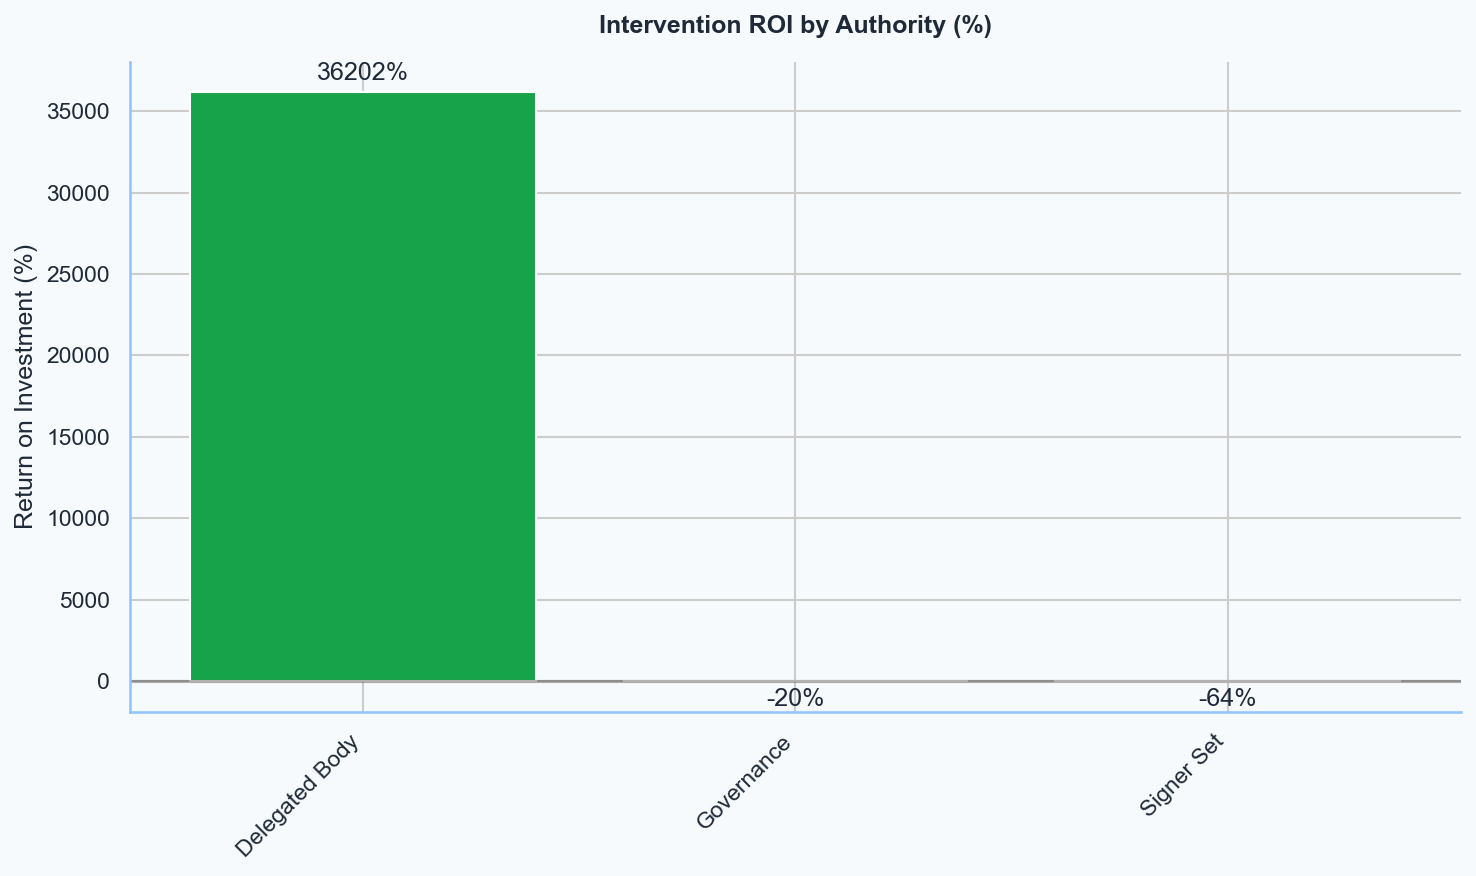

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_intervention_roi.png


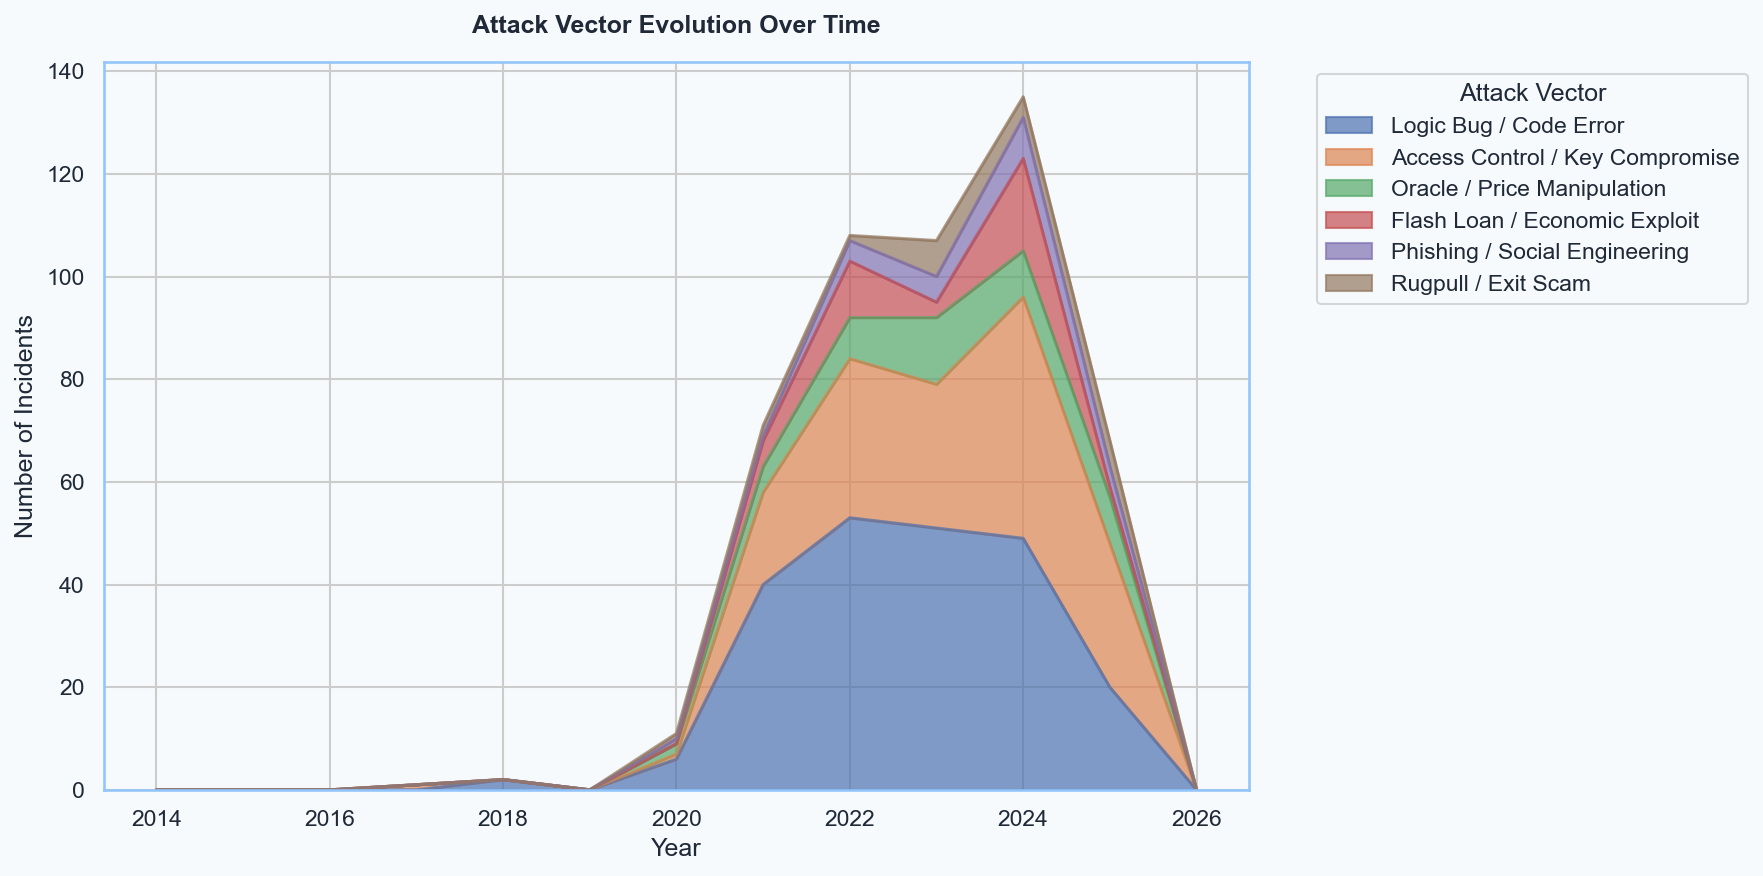

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_attack_vector_evolution.png


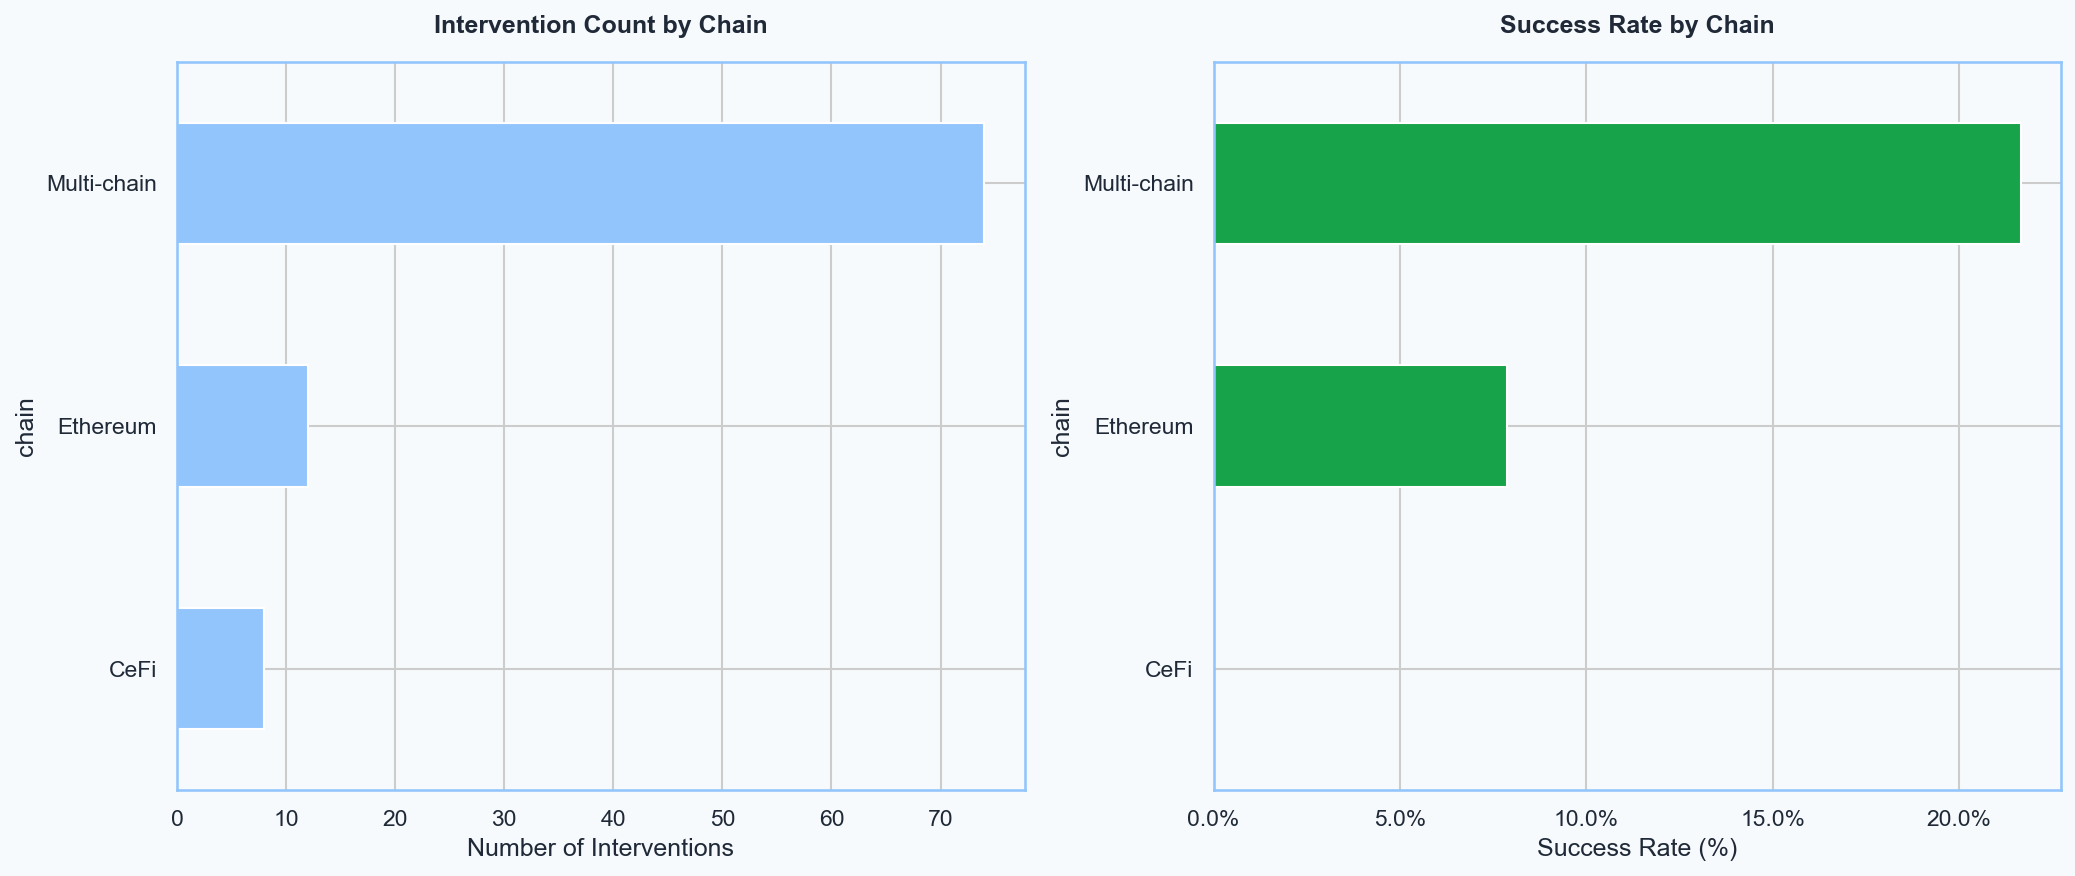

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_chain_intervention_analysis.png


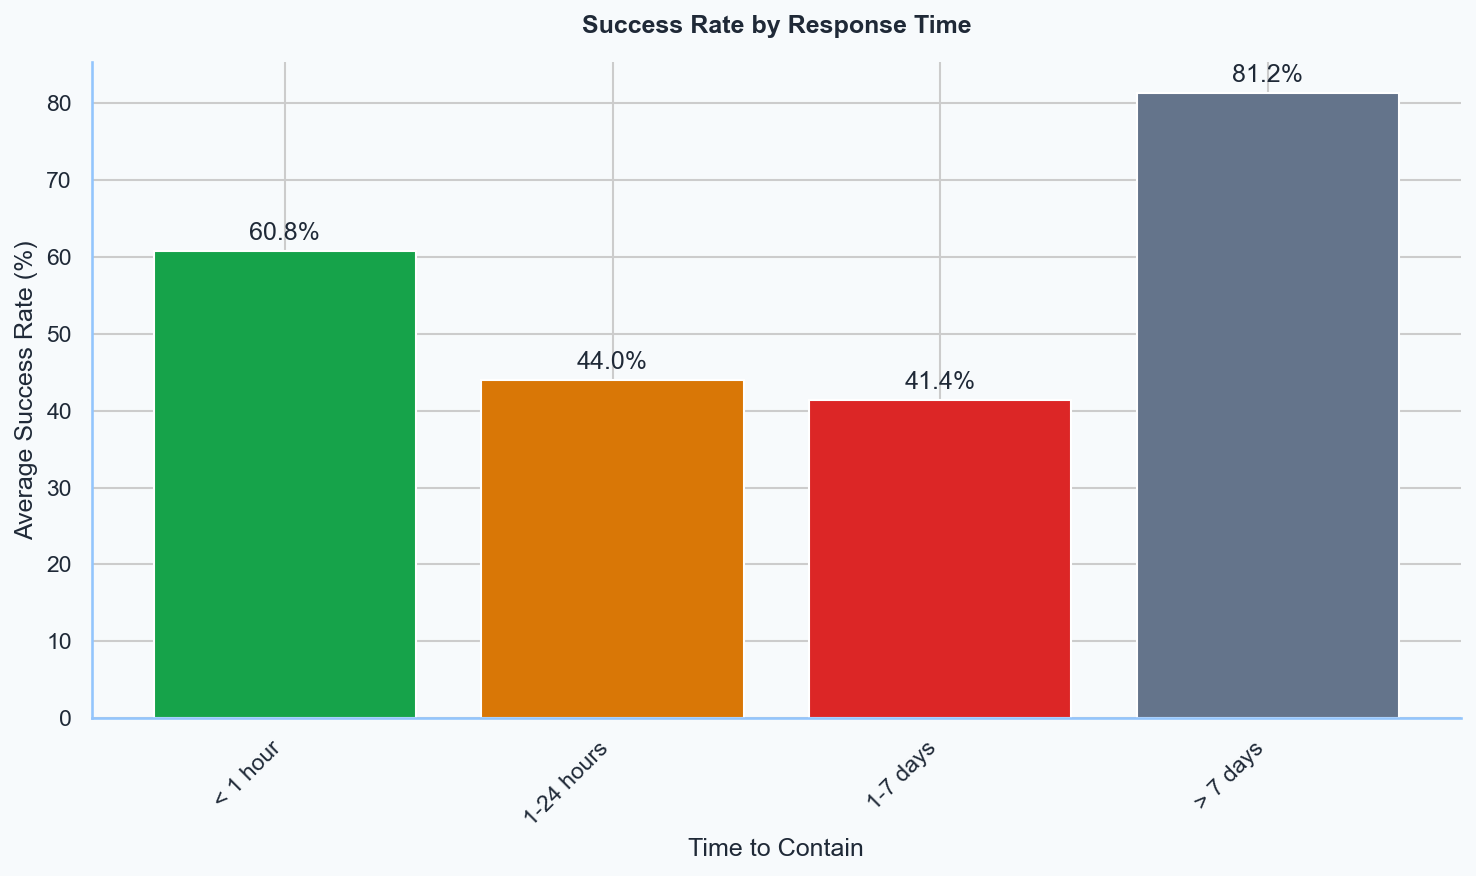

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_response_time_analysis.png
Strategic charts generated. Total charts: 25


In [ ]:
## Additional Strategic Charts

display(Markdown("### 🎯 Strategic Analysis Charts"))
print("Generating additional strategic visualizations...")

# 1. Intervention ROI Analysis
roi_data = []
for _, row in metrics_df.iterrows():
    if row['loss_usd'] > 0:
        roi = (row['loss_prevented_usd'] - row['loss_usd']) / row['loss_usd'] * 100
        roi_data.append({
            'authority': row['authority_standardized'],
            'roi': roi,
            'loss_prevented': row['loss_prevented_usd'],
            'loss_incurred': row['loss_usd']
        })

if roi_data:
    roi_df = pd.DataFrame(roi_data)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    authority_roi = roi_df.groupby('authority')['roi'].mean().sort_values(ascending=False)
    bars = ax.bar(authority_roi.index, authority_roi.values, 
                 color=[COLORS['green'] if x > 0 else COLORS['red'] for x in authority_roi.values])
    ax.bar_label(bars, fmt='%.0f%%', padding=3)
    ax.set_title('Intervention ROI by Authority (%)')
    ax.set_ylabel('Return on Investment (%)')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()
    save_fig(fig, 'v1_intervention_roi.png')
    plt.close(fig)
    chart_count += 1

# 2. Attack Vector Evolution Over Time
vector_yearly = exploits_df.groupby(['year', 'vector_category']).size().unstack(fill_value=0)
# Get top 6 vectors by total frequency
top_vectors = exploits_df['vector_category'].value_counts().head(6).index
vector_yearly = vector_yearly[top_vectors]

fig, ax = plt.subplots(figsize=(12, 6))
vector_yearly.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
ax.set_title('Attack Vector Evolution Over Time')
ax.set_ylabel('Number of Incidents')
ax.set_xlabel('Year')
ax.legend(title='Attack Vector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_attack_vector_evolution.png')
plt.close(fig)
chart_count += 1

# 3. Chain-Specific Intervention Effectiveness
chain_interventions = all_interventions_df.groupby('chain').agg({
    'loss_usd': 'sum',
    'loss_prevented_usd': 'sum',
    'authority_standardized': 'count'
}).rename(columns={'authority_standardized': 'intervention_count'})

chain_interventions['success_rate'] = (
    chain_interventions['loss_prevented_usd'] / 
    (chain_interventions['loss_usd'] + chain_interventions['loss_prevented_usd'])
) * 100

# Filter chains with at least 3 interventions
chain_interventions_filtered = chain_interventions[chain_interventions['intervention_count'] >= 3]

if len(chain_interventions_filtered) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Intervention counts by chain
    chain_interventions_filtered['intervention_count'].sort_values().plot(
        kind='barh', ax=ax1, color=COLORS['blue_light'])
    ax1.set_title('Intervention Count by Chain')
    ax1.set_xlabel('Number of Interventions')
    
    # Success rates by chain
    chain_interventions_filtered['success_rate'].sort_values().plot(
        kind='barh', ax=ax2, color=COLORS['green'])
    ax2.set_title('Success Rate by Chain')
    ax2.set_xlabel('Success Rate (%)')
    ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
    
    plt.tight_layout()
    plt.show()
    save_fig(fig, 'v1_chain_intervention_analysis.png')
    plt.close(fig)
    chart_count += 1

# 4. Time-to-Intervention Analysis
time_analysis = metrics_df.copy()
time_analysis = time_analysis[time_analysis['time_to_detect_min'].notna() & 
                              time_analysis['time_to_contain_min'].notna()]

if len(time_analysis) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create time categories
    time_analysis['response_category'] = pd.cut(
        time_analysis['time_to_contain_min'],
        bins=[0, 60, 1440, 10080, np.inf],
        labels=['< 1 hour', '1-24 hours', '1-7 days', '> 7 days']
    )
    
    response_success = time_analysis.groupby('response_category')['containment_success_pct'].mean()
    
    bars = ax.bar(response_success.index, response_success.values, 
                  color=[COLORS['green'], COLORS['amber'], COLORS['red'], COLORS['slate']])
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_title('Success Rate by Response Time')
    ax.set_ylabel('Average Success Rate (%)')
    ax.set_xlabel('Time to Contain')
    plt.xticks(rotation=45, ha='right')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()
    save_fig(fig, 'v1_response_time_analysis.png')
    plt.close(fig)
    chart_count += 1

print(f"Strategic charts generated. Total charts: {chart_count}")

### 🔮 Predictive & Risk Analysis

Generating predictive and risk assessment charts...


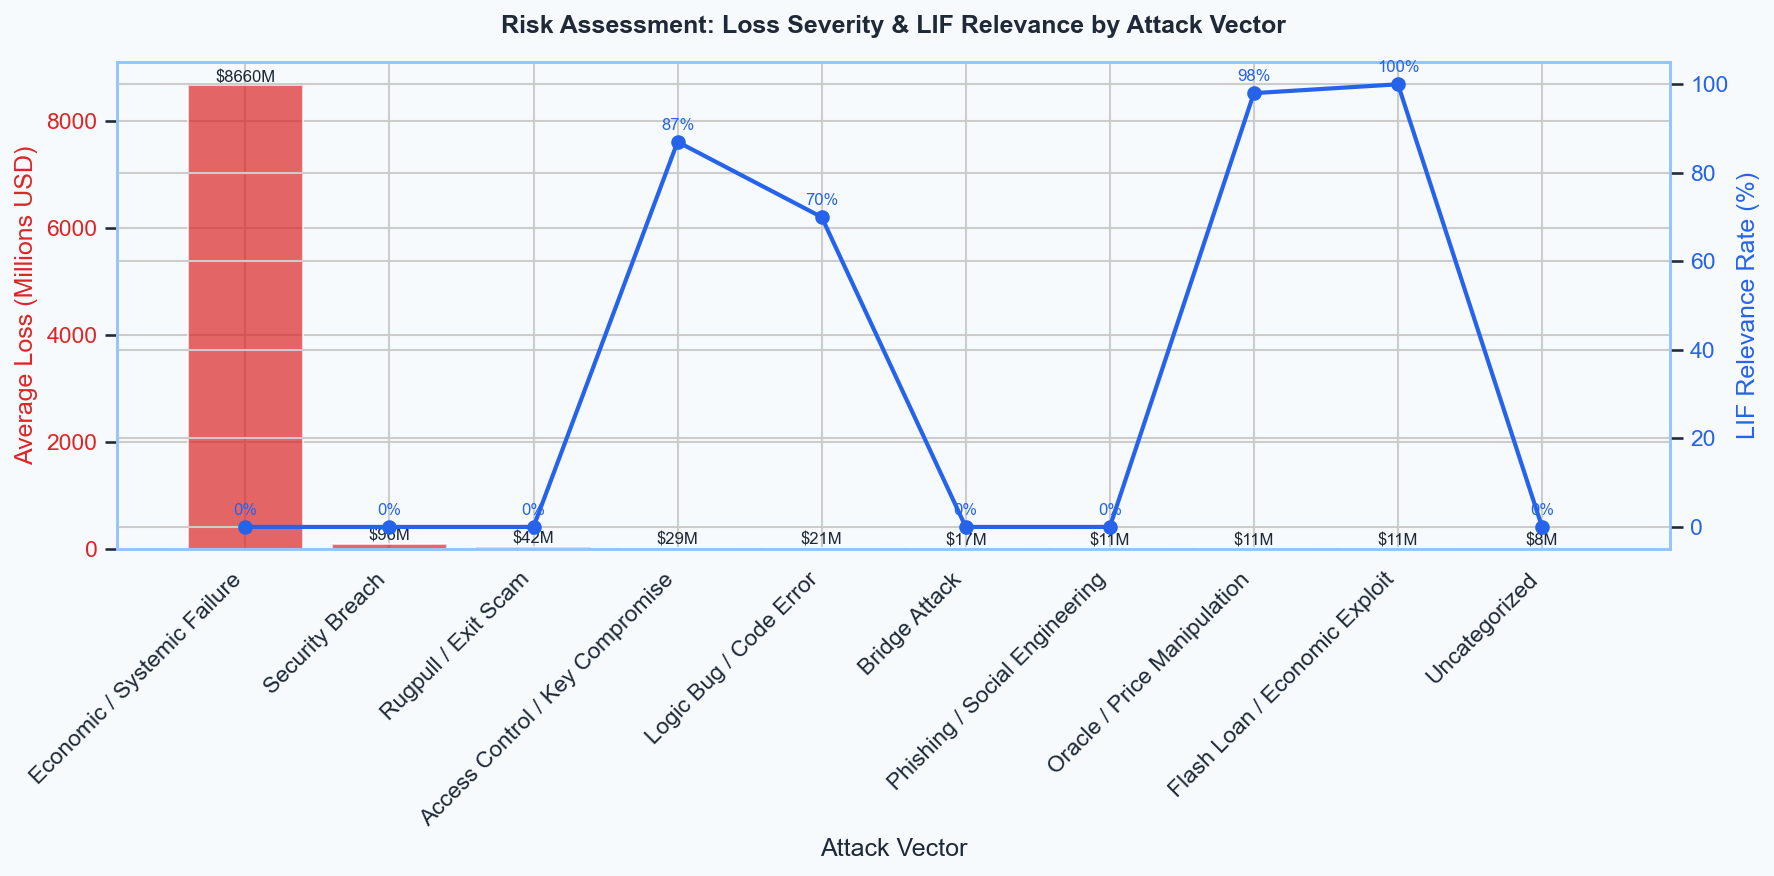

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_risk_assessment_by_vector.png


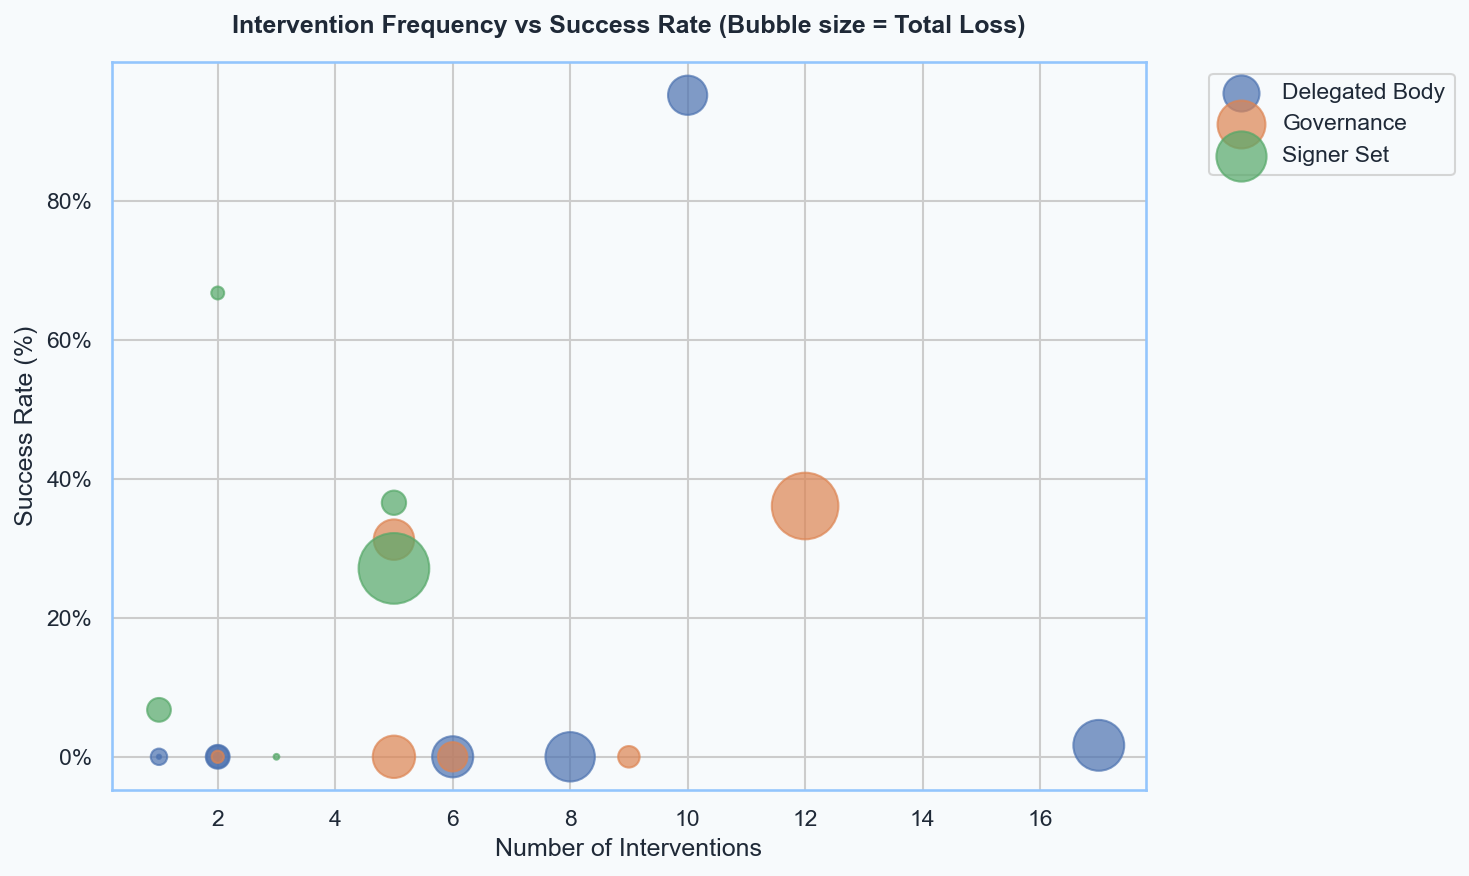

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_frequency_vs_success.png


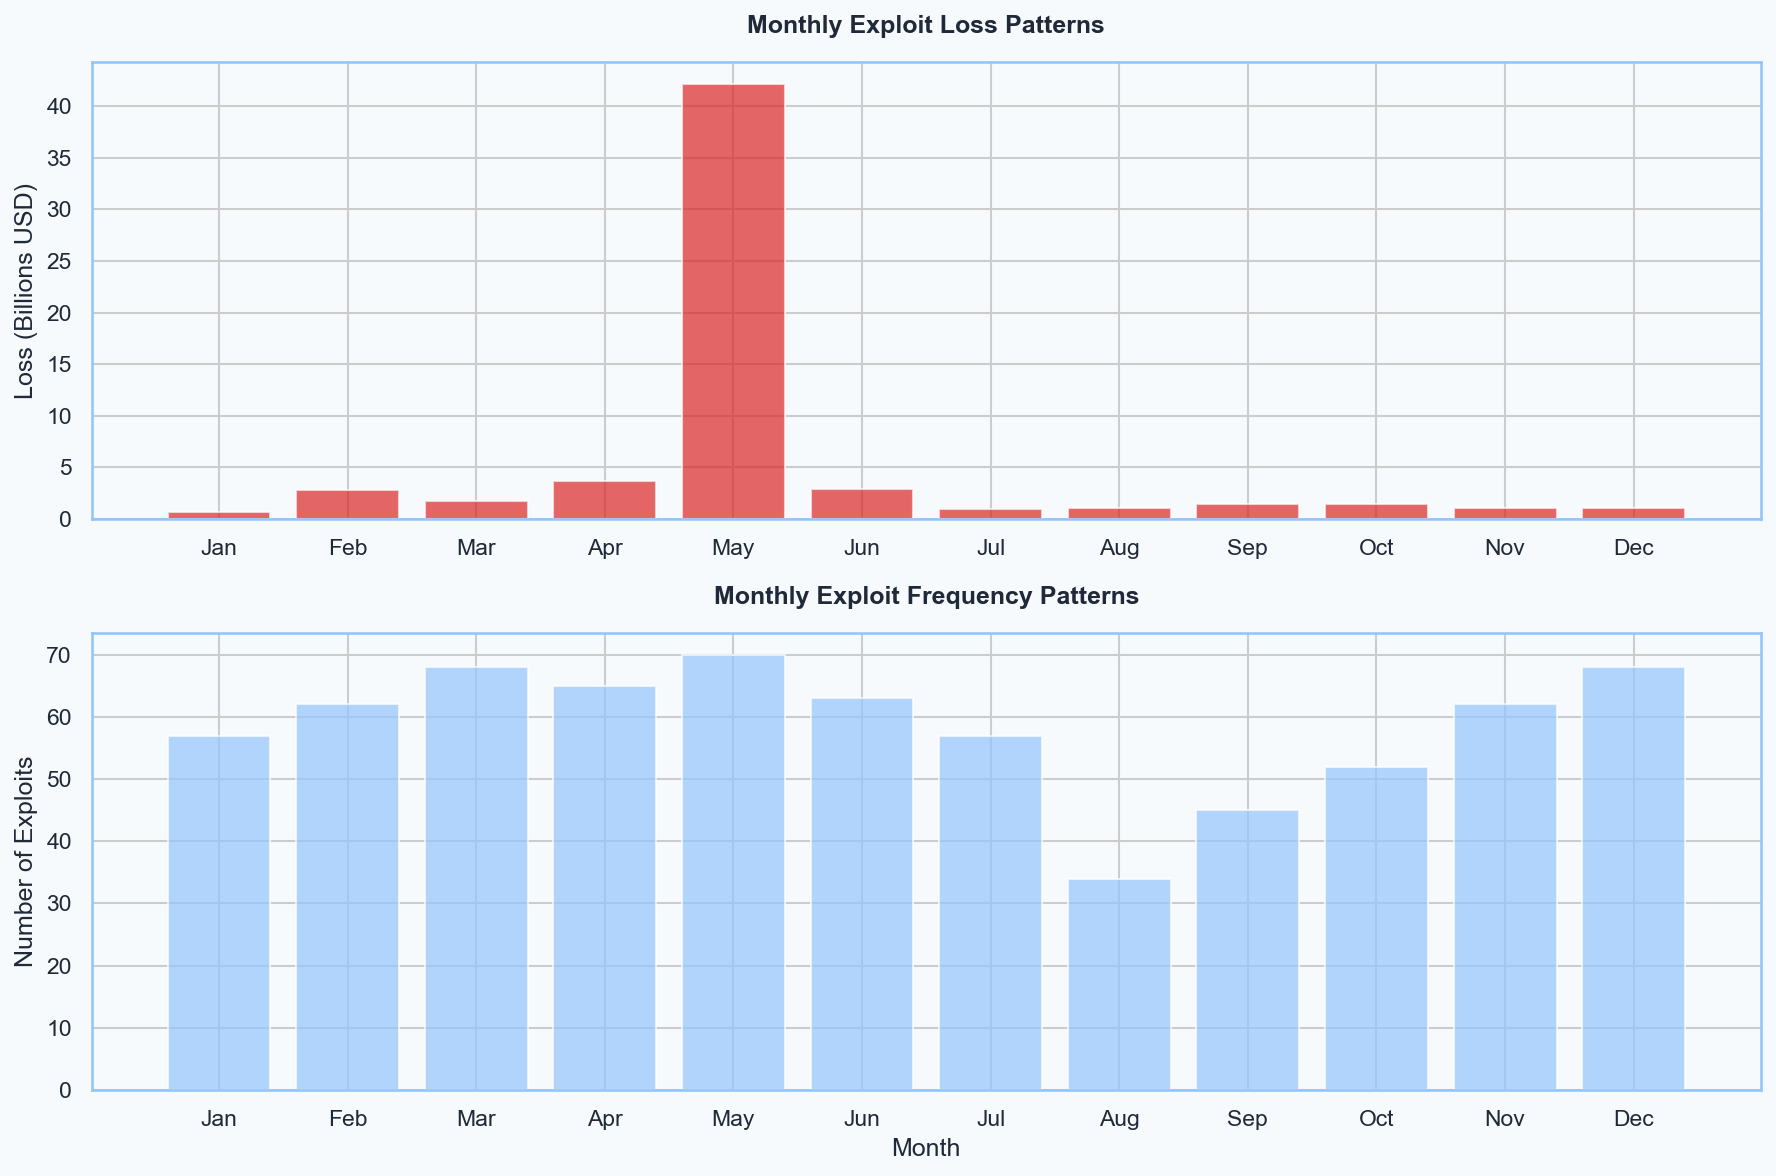

Saved: /Users/elemoghenekaro/Desktop/tasks/legitimate-intervention-framework/visualizations/v1/v1_seasonal_patterns.png


ValueError: x and y must have same first dimension, but have shapes (16,) and (15,)

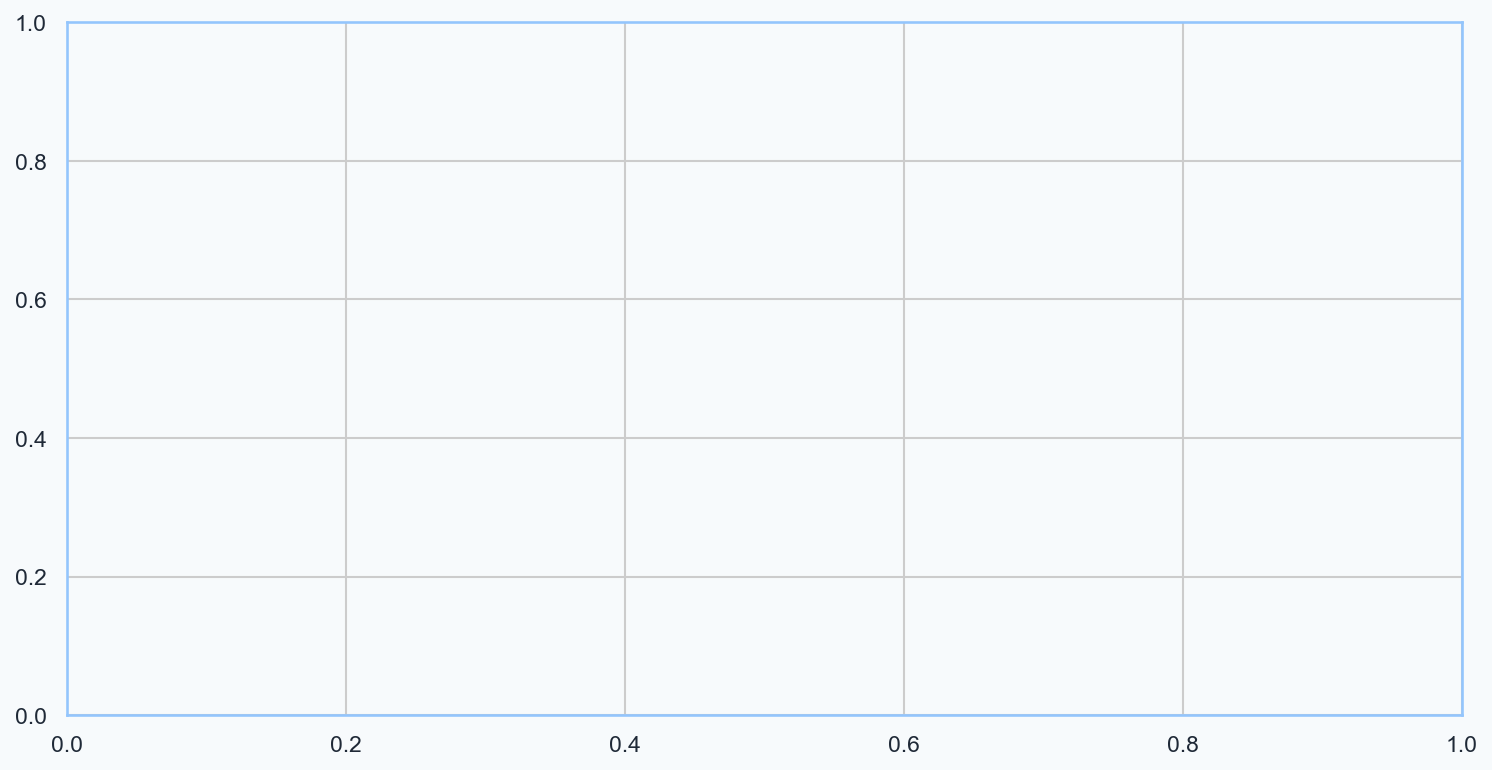

In [ ]:
## Predictive & Risk Analysis Charts

display(Markdown("### 🔮 Predictive & Risk Analysis"))
print("Generating predictive and risk assessment charts...")

# 1. Loss Severity Prediction by Vector
vector_severity = exploits_df.groupby('vector_category').agg({
    'loss_usd': ['mean', 'median', 'count'],
    'is_lif_relevant': 'mean'
}).round(2)
vector_severity.columns = ['avg_loss', 'median_loss', 'count', 'lif_relevance_rate']
vector_severity = vector_severity[vector_severity['count'] >= 3]  # Filter for significance
vector_severity = vector_severity.sort_values('avg_loss', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(vector_severity))
bars = ax.bar(x_pos, vector_severity['avg_loss'] / 1e6, color=COLORS['red'], alpha=0.7)
ax2 = ax.twinx()
ax2.plot(x_pos, vector_severity['lif_relevance_rate'] * 100, 'o-', color=COLORS['blue'], linewidth=2)
ax2.set_ylabel('LIF Relevance Rate (%)', color=COLORS['blue'])
ax2.tick_params(axis='y', labelcolor=COLORS['blue'])

ax.set_xlabel('Attack Vector')
ax.set_ylabel('Average Loss (Millions USD)', color=COLORS['red'])
ax.set_title('Risk Assessment: Loss Severity & LIF Relevance by Attack Vector')
ax.set_xticks(x_pos)
ax.set_xticklabels(vector_severity.index, rotation=45, ha='right')
ax.tick_params(axis='y', labelcolor=COLORS['red'])

# Add value labels
for i, (avg_loss, relevance) in enumerate(zip(vector_severity['avg_loss'], vector_severity['lif_relevance_rate'])):
    ax.text(i, avg_loss/1e6 + 0.5, f'${avg_loss/1e6:.0f}M', ha='center', va='bottom', fontsize=8)
    ax2.text(i, relevance*100 + 2, f'{relevance*100:.0f}%', ha='center', va='bottom', fontsize=8, color=COLORS['blue'])

plt.tight_layout()
plt.show()
save_fig(fig, 'v1_risk_assessment_by_vector.png')
plt.close(fig)
chart_count += 1

# 2. Intervention Frequency vs Success Scatter
intervention_analysis = all_interventions_df.groupby(['year', 'authority_standardized']).agg({
    'loss_usd': 'sum',
    'loss_prevented_usd': 'sum',
    'protocol': 'count'
}).rename(columns={'protocol': 'intervention_count'})

intervention_analysis['success_rate'] = (
    intervention_analysis['loss_prevented_usd'] / 
    (intervention_analysis['loss_usd'] + intervention_analysis['loss_prevented_usd'])
) * 100

fig, ax = plt.subplots(figsize=(10, 6))
for authority in intervention_analysis.index.get_level_values('authority_standardized').unique():
    auth_data = intervention_analysis.xs(authority, level='authority_standardized')
    if len(auth_data) > 0:
        ax.scatter(auth_data['intervention_count'], auth_data['success_rate'], 
                  s=auth_data['loss_usd']/1e6, alpha=0.7, label=authority)

ax.set_xlabel('Number of Interventions')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Intervention Frequency vs Success Rate (Bubble size = Total Loss)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()
save_fig(fig, 'v1_frequency_vs_success.png')
plt.close(fig)
chart_count += 1

# 3. Seasonal Pattern Analysis
exploits_df['month'] = pd.to_datetime(exploits_df['date']).dt.month
monthly_losses = exploits_df.groupby('month')['loss_usd'].sum() / 1e9
monthly_counts = exploits_df.groupby('month').size()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Monthly loss patterns
ax1.bar(monthly_losses.index, monthly_losses.values, color=COLORS['red'], alpha=0.7)
ax1.set_title('Monthly Exploit Loss Patterns')
ax1.set_ylabel('Loss (Billions USD)')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Monthly frequency patterns
ax2.bar(monthly_counts.index, monthly_counts.values, color=COLORS['blue_light'], alpha=0.7)
ax2.set_title('Monthly Exploit Frequency Patterns')
ax2.set_ylabel('Number of Exploits')
ax2.set_xlabel('Month')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()
save_fig(fig, 'v1_seasonal_patterns.png')
plt.close(fig)
chart_count += 1

# 4. Early Warning Indicators (Fixed)
# Calculate time between exploits for each chain
chain_exploits = exploits_df[exploits_df['date'].notna()].sort_values(['chain', 'date'])
chain_exploits['days_since_previous'] = chain_exploits.groupby('chain')['date'].diff().dt.days

# Analyze chains with frequent exploits
frequent_chains = chain_exploits.groupby('chain').size()
frequent_chains = frequent_chains[frequent_chains >= 5].index

if len(frequent_chains) > 0:
    frequent_chain_data = chain_exploits[chain_exploits['chain'].isin(frequent_chains)]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    for chain in frequent_chains:
        chain_data = frequent_chain_data[frequent_chain_data['chain'] == chain]
        if len(chain_data) > 1:
            # Fix: Use only non-NaN values and match x and y dimensions
            days_data = chain_data['days_since_previous'].dropna()
            if len(days_data) > 0:
                x_vals = range(len(days_data))
                ax.plot(x_vals, days_data, 'o-', label=chain, alpha=0.7)
    
    ax.set_title('Time Between Exploits by Chain (Early Warning Patterns)')
    ax.set_xlabel('Exploit Sequence Number')
    ax.set_ylabel('Days Since Previous Exploit')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    save_fig(fig, 'v1_early_warning_patterns.png')
    plt.close(fig)
    chart_count += 1

print(f"Predictive & risk charts generated. Total charts: {chart_count}")

In [ ]:
## Additional Comparative Analysis

display(Markdown("### 🔄 Comparative Analysis: All vs Detailed Interventions"))
print("Generating comparative analysis between all interventions and detailed metrics...")

# 1. Authority Distribution Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# All interventions authority distribution
all_auth_counts = all_interventions_df['authority_standardized'].value_counts()
bars1 = ax1.bar(all_auth_counts.index, all_auth_counts.values, color=COLORS['blue'], alpha=0.7)
ax1.bar_label(bars1, padding=3)
ax1.set_title('Authority Distribution (All Interventions)')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Authority Type')
ax1.tick_params(axis='x', rotation=45)

# Detailed metrics authority distribution
detailed_auth_counts = metrics_df['authority_standardized'].value_counts()
bars2 = ax2.bar(detailed_auth_counts.index, detailed_auth_counts.values, color=COLORS['green'], alpha=0.7)
ax2.bar_label(bars2, padding=3)
ax2.set_title('Authority Distribution (Detailed Metrics)')
ax2.set_ylabel('Number of Cases')
ax2.set_xlabel('Authority Type')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
save_fig(fig, 'v1_authority_distribution_comparison.png')
plt.close(fig)
chart_count += 1

# 2. Scope Distribution Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# All interventions scope distribution
all_scope_counts = all_interventions_df['scope_category'].value_counts()
bars1 = ax1.bar(all_scope_counts.index, all_scope_counts.values, color=COLORS['purple'], alpha=0.7)
ax1.bar_label(bars1, padding=3)
ax1.set_title('Scope Distribution (All Interventions)')
ax1.set_ylabel('Number of Cases')
ax1.set_xlabel('Scope Category')
ax1.tick_params(axis='x', rotation=45)

# Detailed metrics scope distribution
detailed_scope_counts = metrics_df['scope_category'].value_counts()
bars2 = ax2.bar(detailed_scope_counts.index, detailed_scope_counts.values, color=COLORS['amber'], alpha=0.7)
ax2.bar_label(bars2, padding=3)
ax2.set_title('Scope Distribution (Detailed Metrics)')
ax2.set_ylabel('Number of Cases')
ax2.set_xlabel('Scope Category')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
save_fig(fig, 'v1_scope_distribution_comparison.png')
plt.close(fig)
chart_count += 1

# 3. Success Rate Comparison by Authority
# Calculate success rates for all interventions
all_success_rates = all_interventions_df.groupby('authority_standardized').apply(
    lambda x: (x['loss_prevented_usd'] / (x['loss_usd'] + x['loss_prevented_usd'])).mean() * 100
).dropna()

# Detailed metrics success rates
detailed_success_rates = metrics_df.groupby('authority_standardized')['containment_success_pct'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(all_success_rates.index))
width = 0.35

bars1 = ax.bar(x_pos - width/2, all_success_rates.values, width, 
               label='All Interventions', color=COLORS['blue'], alpha=0.7)
bars2 = ax.bar(x_pos + width/2, detailed_success_rates.reindex(all_success_rates.index).values, width,
               label='Detailed Metrics', color=COLORS['green'], alpha=0.7)

ax.set_xlabel('Authority Type')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Success Rate Comparison by Authority')
ax.set_xticks(x_pos)
ax.set_xticklabels(all_success_rates.index, rotation=45, ha='right')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Add value labels
for bars in [bars1, bars2]:
    ax.bar_label(bars, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()
save_fig(fig, 'v1_success_rate_comparison.png')
plt.close(fig)
chart_count += 1

# 4. Coverage Analysis
coverage_stats = pd.DataFrame({
    'Dataset': ['All Interventions', 'Detailed Metrics'],
    'Total Cases': [len(all_interventions_df), len(metrics_df)],
    'Unique Authorities': [all_interventions_df['authority_standardized'].nunique(), 
                          metrics_df['authority_standardized'].nunique()],
    'Unique Scopes': [all_interventions_df['scope_category'].nunique(), 
                     metrics_df['scope_category'].nunique()],
    'Total Loss (USD)': [all_interventions_df['loss_usd'].sum(), metrics_df['loss_usd'].sum()],
    'Total Prevented (USD)': [all_interventions_df['loss_prevented_usd'].sum(), 
                             metrics_df['loss_prevented_usd'].sum()]
})

print("\n📊 Dataset Coverage Comparison:")
print(coverage_stats.to_string(index=False))

# Calculate coverage percentages
coverage_pct = (len(metrics_df) / len(all_interventions_df)) * 100
print(f"\n📈 Detailed metrics cover {coverage_pct:.1f}% of all intervention cases")

print(f"\nComparative analysis charts generated. Total charts: {chart_count}")